# Overview (Donor)
* Separate male/female from the dataset
* Add medication to the male/female dataset
* Impute NaNs

In [1]:
# path to user functions
import sys  
sys.path.append('../Src/')

import pandas as pd
import pickle
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import sys

from scipy import stats
from importlib.metadata import version

# set seaborn theme
sns.set_theme()

# python modules
import utilities as u
import plot

# initializing variables
SEED = 1776

# Create a dictionary of versions
versions = {
    "Python": sys.version.split()[0],
    "Pandas": pd.__version__,
    "NumPy": np.__version__,
    "Seaborn": sns.__version__,
    "Matplot": sys.modules['matplotlib'].__version__,
    # "Sk-Learn": sys.modules['sklearn'].__version__,
    "Scipy": sys.modules['scipy'].__version__,
}

# Display as a clean DataFrame
df_versions = pd.DataFrame(list(versions.items()), columns=['Library', 'Version'])
print(df_versions)

# adjust pandas display options to max
pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)
# adjust pandas display options to ensure full display of content
pd.set_option('display.max_colwidth', None)

   Library  Version
0   Python  3.11.13
1   Pandas    2.3.1
2    NumPy    2.3.2
3  Seaborn   0.13.2
4  Matplot   3.10.5
5    Scipy   1.16.1


## Import Data

In [2]:
# import data
df = pd.read_pickle("../Data/DON_Heart_Data.pkl")
# display 
df.head()

,DeceasedRetyped_DON,AntigenDA1_DON,AntigenDA2_DON,AntigenDB1_DON,AntigenDB2_DON,AntigenDDR1_DON,AntigenDDR2_DON,Citizenship_DON,PastCocaineUse_DON,Age_DON,Ethnicity_DON,Hepatitis_B_CoreAntibody_DON,SurfaceAntigenHEP_B_DON,BloodGroup_DON,HeavyAlcoholUse_DON,DeceasedOrLiving_DON,Gender_DON,ResidencyState_DON,Antibody_HEP_C_DON,NonHeartBeating_DON,AntiHypertensive_DON,BloodInfectionSource_DON,BloodUreaNitrogenLevel_DON,Creatinine_DON,OtherInfectionSource_DON,Diuretics_DON,SteroidsUse_DON,TriiodothyronineT3_DON,ThyroxineT4_DON,OtherMedsText2_DON,OtherMedsText3_DON,OtherMedsText1_DON,PulmonaryInfection_DON,PULM_INF_CONF_DON,Level_SGOT_AST_DON,Level_SGOT_ALT_DON,TerminalTotalBilirubin_DON,UrineInfection_DON,Vasodilators_DON,AntibodyResultRPR_VDRL_DON,InfectionClinical_DON,CocaineUse_DON,OtherDrugUse_DON,CancerExtraCranial_DON,CancerSite_DON,CigaretteHistory_DON,HypertensionHistory_DON,CancerIntraCranial_DON,CancerHistory_DON,DiabetesHistory_DON,Diabetes_DON,PastOtherDrugUse_DON,CancerSkin_DON,SerologyAntiCMV_DON,CauseOfDeath_DON,SyntheticAntiDiureticHormone_DON,DeathCircumstance_DON,DeathMechanism_DON,HeparinManagement_DON,ArginnieManagement_DON,InsulinManagement_DON,Height_cm_DON,Weight_kg_DON,BMI_Donation_DON,HBV_NAT_Result_DON,HCV_NAT_Result_DON,HIV_NAT_Result_DON,IschemicTimeHour_DON,AllocationType_DON,UrineProtein_DON,CardiacArrest_DON,LungPO2_DON,MyocardialInfarctionHistory_DON,LV_EjectionFractionMedthod_DON,LV_EjectionFractionPercent_DON,CoronaryAngiogram_DON,Biopsy_DON,Tatoos_DON,AntibodyResultHBSAB_DON,EpsteinBarr_IGG_DON,EpsteinBarr_IGM_DON,HIV_Risk_DON,InotropicAgent_DON,KidneyAllocation_DON,InotropicMedicationProcurement_DON,TransfusionNumber_DON,LungPO2_Done_DON,LungPO2_FIO2_DON,OrganRecovery_PCO2_DON,PulmonaryCatheter_DON,BronchoscopyLeft_DON,BronchoscopyRight_DON,ChestXray_DON,BloodPH_DON,Hematocrit_DON,TransplantSurvivalDay,CrossMatchDone,MismatchLevel_AMIS,MismatchLevel_BMIS,MismatchLevel_DRMIS,MismatchLevel_HLAMIS,BloodGroupMatchLevel
0,No,2,29,44,49,4,15,US Citizen,No,31,Black,Negative,Negative,A,No,Deceased Donor,M,CA,Negative,No,Yes,No,18.0,1.30,No,Yes,No,No,No,"KCL,","DOPAMINE, VASOPRESSIN,","ZOSYN, VANCOMYCIN",Yes,Yes,46.0,40.0,0.4,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,Yes,HOMICIDE,GUNSHOT WOUND,Yes,No,Yes,172.7,107.0,35.867286,Unknown,Unknown,Unknown,4.9,Local,No,No,182.0,No,Echo,60.0,No,Biopsy not done,Yes,Not Done,Positive,Negative,No,Unknown,No,No,1 - 5,Yes,47.0,40.0,No,Normal,Normal,Abnormal-right,7.38,26.2,329.0,No,2,2,1,5,Identical
1,Yes,2,68,49,60,10,16,Non-US Citizen/US Resident,No,30,Hispanic,Negative,Negative,O,No,Deceased Donor,M,TX,Negative,No,No,No,29.0,0.70,No,Yes,No,No,Yes,NaN,NaN,"ANCEF, FENTANYL, VERSED,LASIX",Yes,Yes,38.0,171.0,0.8,No,No,Negative,Yes,Unknown,Unknown,No,NO,No,No,No,No,No,No,No,No,Positive,HEAD TRAUMA,No,"Accident, Non-MVA",BLUNT INJURY,Yes,Yes,No,172.7,67.1,22.492476,Unknown,Unknown,Unknown,3.1,Local,No,No,323.0,No,Echo,55.0,No,Biopsy not done,No,Not Done,Positive,Negative,No,Dopamine,No,Yes,6 - 10,Yes,100.0,28.0,No,Normal,Normal,Abnormal-left,7.50,27.8,2592.0,Yes,1,2,2,5,Identical
2,No,2,3,7,44,11,15,US Citizen,No,15,"White, Non-Hispanic",Negative,Negative,O,No,Deceased Donor,M,NY,Negative,No,No,No,15.0,0.74,No,Yes,Yes,No,Yes,"AMPHOTERICIN, BETADINE",ZANTAC,"ZOSYN, VANCOMYCIN",Yes,Yes,445.0,217.0,0.7,No,No,Negative,Yes,Unknown,Yes,No,NO,No,No,No,No,No,No,Yes,No,Negative,ANOXIA,No,NONE OF THE ABOVE,DRUG INTOXICATION,Yes,Yes,No,170.0,59.0,20.415225,Unknown,Unknown,Unknown,1.4,Local,No,No,401.0,No,Echo,60.0,No,Biopsy not done,No,Not Done,Negative,Negative,No,"Other, specify",No,Yes,NONE,Yes,100.0,41.0,No,Normal,Unknwn,Abnormal-both,7.40,25.4,2913.0,Yes,0,1,2,3,Identical
3,Yes,33,68,39,51,1,8,US Citizen,No,47,"White, Non-Hispanic",Negative,Negative,A1,No,Deceased Donor,F,NY,Negative,No,Yes,Yes,29.0,1.34,No,Yes,Yes,No,Yes,"D50, DOPAMINE, DIFLUCAN",NaN,"KCL, VANCO, MAG, ZOSYN",Yes,Yes,248.0,165.0,0.3,Yes,No,Negative,Yes,Unknown,Yes,

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30298 entries, 0 to 30297
Columns: 102 entries, DeceasedRetyped_DON to BloodGroupMatchLevel
dtypes: category(82), float64(16), int64(1), object(3)
memory usage: 7.0+ MB


## Combine Meds

In [4]:
# select column name
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
cols = sorted(cols)
df[cols].sample(n=10, random_state=SEED)

,OtherMedsText1_DON,OtherMedsText2_DON,OtherMedsText3_DON
24713,NaN,NaN,NaN
12770,"ZOSYN,MICAFUNGIN",VANCOMYCIN,VECURONIUM
12524,"VANCOMYCIN,ZOSYN",ROCURONIUIM,ALBUMIN
14592,"ALBUTEROL, ZOSYN, VANCO","CEFEPIME, ROCURONIUM",NaN
15126,"ALBUTEROL,ZOSYN",VANCOMYCIN,"ROCURONIUM,NEOSYNEPHRINE"
153,"ZOSYN, ALBUTEROL, DOBUTAMINE,",NaN,NaN
10572,VANCOMYCIN,"ROCURONIUM, FENTANYL",NaN
16252,"CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE,","VANCOMYCIN, ROCURONIUM",NaN
25907,"KCL, CEFEPIME, FLAGYL","VANCOMYCIN, LEVOPHED","NEOSYNEPHRINE, VECURONIUM"
3987,ZOSYN,VANCOMYCIN,ALBUTEROL


In [5]:
df["Meds_DON"] = (
    df[cols].fillna("")
    .agg(", ".join, axis=1)

    # Normalize separators: convert ., /, ;, : to commas
    .str.replace(r"[./;:]", ",", regex=True)

    # Fix double commas
    .str.replace(r",\s*,", ",", regex=True)

    # Normalize comma spacing (remove spaces before/after)
    .str.replace(r"\s*,\s*", ", ", regex=True)

    # Strip trailing commas/spaces
    .str.strip(", ")
)
df["Meds_DON"].sample(n=10, random_state=SEED)

24713                                                                          
12770                                 ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                                   VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                             ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126                   ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                                ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                          VANCOMYCIN, ROCURONIUM, FENTANYL
16252            CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25907    KCL, CEFEPIME, FLAGYL, VANCOMYCIN, LEVOPHED, NEOSYNEPHRINE, VECURONIUM
3987                                               ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds_DON, dtype: object

In [6]:
def dedupe_meds(x):
    parts = [p.strip() for p in x.split(",") if p.strip()]
    seen = set()
    unique = []
    for med in parts:
        key = med.upper()
        if key not in seen:
            seen.add(key)
            unique.append(med)
    return ", ".join(unique)

df["Meds_DON"] = df["Meds_DON"].apply(dedupe_meds)
# new feature
df["Meds_DON"].sample(n=10, random_state=SEED)

24713                                                                          
12770                                 ZOSYN, MICAFUNGIN, VANCOMYCIN, VECURONIUM
12524                                   VANCOMYCIN, ZOSYN, ROCURONIUIM, ALBUMIN
14592                             ALBUTEROL, ZOSYN, VANCO, CEFEPIME, ROCURONIUM
15126                   ALBUTEROL, ZOSYN, VANCOMYCIN, ROCURONIUM, NEOSYNEPHRINE
153                                                ZOSYN, ALBUTEROL, DOBUTAMINE
10572                                          VANCOMYCIN, ROCURONIUM, FENTANYL
16252            CEFEPIME, CHLORHEXIDINE, METRONIDAZOLE, VANCOMYCIN, ROCURONIUM
25907    KCL, CEFEPIME, FLAGYL, VANCOMYCIN, LEVOPHED, NEOSYNEPHRINE, VECURONIUM
3987                                               ZOSYN, VANCOMYCIN, ALBUTEROL
Name: Meds_DON, dtype: object

In [7]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

In [8]:
# remove
cols = df.columns[df.columns.str.contains("OtherMeds")].tolist()
df = df.drop(cols, axis=1)

## Gender

In [9]:
# any nans
u.any_nans(df)

--- Missing Values Found () (Total Rows: 30,298) ---
                                Count Percentage
IschemicTimeHour_DON              216    0.7129%
LungPO2_FIO2_DON                  186    0.6139%
LungPO2_DON                       108    0.3565%
OrganRecovery_PCO2_DON             83    0.2739%
BloodPH_DON                        77    0.2541%
Level_SGOT_AST_DON                 58    0.1914%
Level_SGOT_ALT_DON                 58    0.1914%
TerminalTotalBilirubin_DON         57    0.1881%
BloodUreaNitrogenLevel_DON         54    0.1782%
Creatinine_DON                     54    0.1782%
Hematocrit_DON                     53    0.1749%
LV_EjectionFractionPercent_DON     34    0.1122%
BMI_Donation_DON                    9    0.0297%
Weight_kg_DON                       3    0.0099%


In [10]:
df.Gender_DON.value_counts(dropna=False)

Gender_DON
M    21365
F     8933
Name: count, dtype: int64

In [11]:
df_m = df[df.Gender_DON == 'M'].copy()
df_f = df[df.Gender_DON == 'F'].copy()
#
df_m.shape, df_f.shape

((21365, 100), (8933, 100))

## Medication

* **Zosyn** (piperacillin/tazobactam) is a powerful, hospital-grade intravenous antibiotic combination used to treat severe bacterial infections, including pneumonia, intra-abdominal infections, and skin infections. It works by combining piperacillin, a penicillin-class antibiotic, with tazobactam, which protects piperacillin from degradation, allowing it to kill bacteria.
* **Rocuronium** (brand name Zemuron) is an intermediate-acting, nondepolarizing neuromuscular blocking agent (paralytic) used during surgery or critical care. It is administered intravenously as an adjunct to general anesthesia to relax skeletal muscles, facilitating rapid sequence and routine tracheal intubation.
* **Vancomycin** is a powerful glycopeptide antibiotic used to treat severe, resistant gram-positive bacterial infections, including MRSA and C. difficile. It works by inhibiting bacterial cell wall synthesis, making it a bactericidal agent. It is administered intravenously for systemic infections and orally for gut-specific infections.
* **Albuterol** is a fast-acting bronchodilator (short-acting beta2-agonist) used to open airways in the lungs, commonly known as a "rescue inhaler" for asthma and COPD. It treats wheezing and breathing difficulties by relaxing airway muscles.
* **Ancef (cefazolin)** is a first-generation cephalosporin antibiotic used to treat various bacterial infections—including skin, bone, joint, and urinary tract infections—and is commonly given intravenously before surgery to prevent infections. It works by inhibiting bacterial cell wall synthesis.
* **Neo-Synephrine** (phenylephrine) is a medication used primarily as a nasal decongestant to temporarily relieve a stuffy nose and sinus pressure from colds, allergies, and hay fever. It works as a vasoconstrictor, narrowing blood vessels in the nasal passages to reduce swelling and improve breathing.
* **Vecuronium** (brand name: Norcuron) is a non-depolarizing neuromuscular blocking agent used to produce skeletal muscle relaxation during surgery, tracheal intubation, or mechanical ventilation. It works by blocking nerve signals to muscles, resulting in temporary paralysis, but it does not cause sedation.
* **Levophed** (norepinephrine bitartrate) is a potent vasopressor medication used in emergency settings to treat severe, acute low blood pressure (hypotension) by rapidly constricting blood vessels and increasing blood pressure. It is administered via intravenous (IV) infusion in critical care, often in conditions like septic shock
* **KCl** (Potassium chloride) is an electrolyte supplement used to prevent or treat low blood potassium levels (hypokalemia), often caused by diuretics or illnesses. It supports heart, muscle, and nerve function, available as oral tablets/powders or IV.
* **Cefepime** is a fourth-generation, broad-spectrum cephalosporin antibiotic used to treat severe infections, including pneumonia, urinary tract infections, and febrile neutropenia. It acts by inhibiting bacterial cell wall synthesis and is effective against Gram-positive and Gram-negative bacteria, including Pseudomonas aeruginosa. Administered via IV or intramuscular injection, it is generally well-tolerated.
* **Fentanyl** is a potent synthetic opioid drug approved by the Food and Drug Administration for use as an analgesic (pain relief) and an anesthetic.
* **Albumin** (human) injection is a sterile, liquid protein solution derived from human plasma used to treat low blood volume (hypovolemia), shock, and low albumin levels (hypoalbuminemia). It increases blood pressure and plasma volume while reducing fluid leakage into tissues (edema); it is commonly used in critical care, major surgeries, burns, and liver disease.
* **Dopamine** is a critical neurotransmitter and hormone that functions as the brain's "feel-good" messenger, driving reward, motivation, memory, and motor control. Produced in the brain, it reinforces pleasurable behaviors and helps regulate focus.
* **Phenylephrine** is an alpha-1 adrenergic receptor agonist (drug class) used primarily as a nasal decongestant (oral/nasal) and to treat hypotension (injection). It acts by constricting blood vessels, thereby reducing nasal congestion and raising blood pressure. However, the FDA has proposed removing oral phenylephrine due to a lack of efficacy.
* **DuoNeb** (ipratropium bromide and albuterol sulfate) is a prescription inhalation solution used to treat reversible airway obstruction, specifically for COPD, chronic bronchitis, and emphysema. It acts as a bronchodilator, relaxing airway smooth muscle, reducing mucus, and improving breathing. It is administered via a nebulizer, generally four times a day.

### Male

In [12]:
# NaN check
df_m.Meds_DON.isna().any()

np.False_

In [13]:
u.get_top_frequencies(df_m, 'Meds_DON', top_n=10, sep=",")

[('ZOSYN', 9835),
 ('ROCURONIUM', 6380),
 ('VANCOMYCIN', 5665),
 ('ALBUTEROL', 4431),
 ('ANCEF', 4425),
 ('NEOSYNEPHRINE', 3981),
 ('LEVOPHED', 3799),
 ('VECURONIUM', 3768),
 ('KCL', 2967),
 ('CEFEPIME', 2258)]

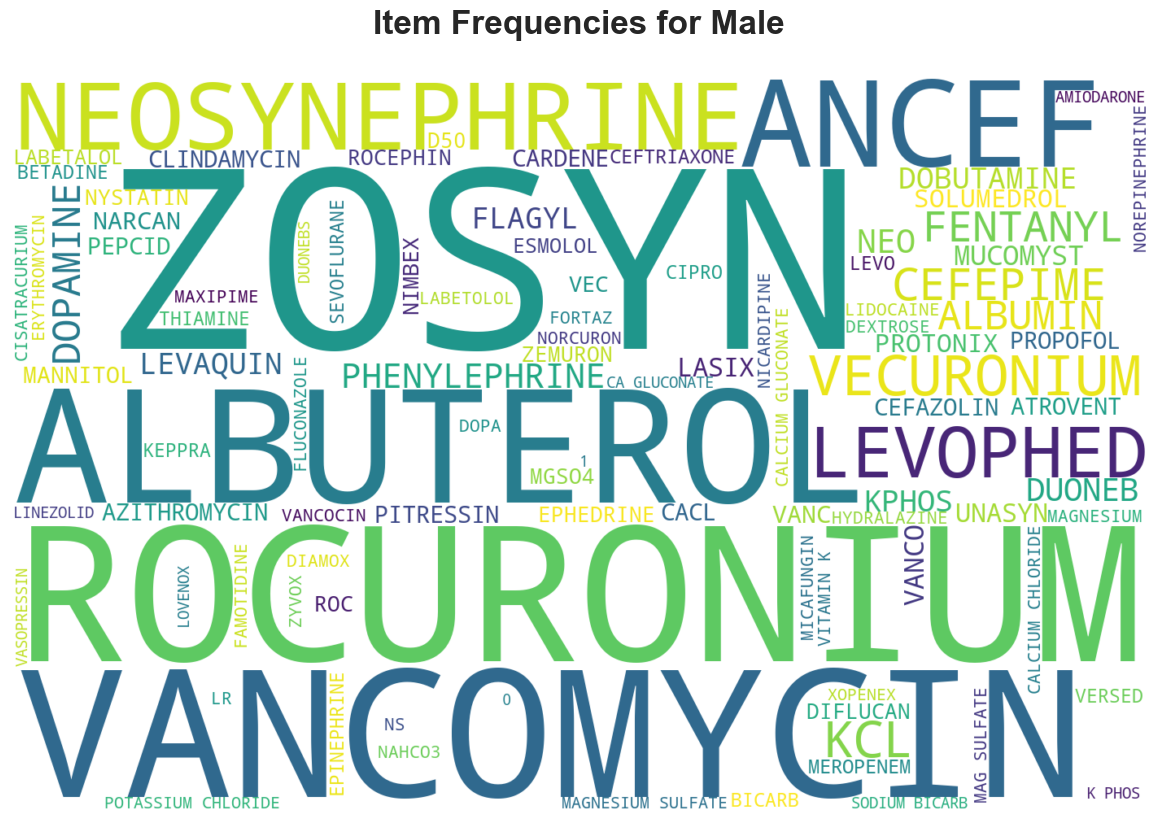

In [14]:
plot.plot_item_wordcloud(df_m.Meds_DON, title="Item Frequencies for Male", bg_color="white")

### Female

In [15]:
# NaN check
df_f.Meds_DON.isna().any()

np.False_

In [16]:
u.get_top_frequencies(df_f, 'Meds_DON', top_n=10, sep=",")

[('ZOSYN', 3866),
 ('ROCURONIUM', 2559),
 ('VANCOMYCIN', 2271),
 ('ALBUTEROL', 1908),
 ('ANCEF', 1803),
 ('NEOSYNEPHRINE', 1731),
 ('VECURONIUM', 1588),
 ('LEVOPHED', 1568),
 ('KCL', 1359),
 ('CEFEPIME', 979)]

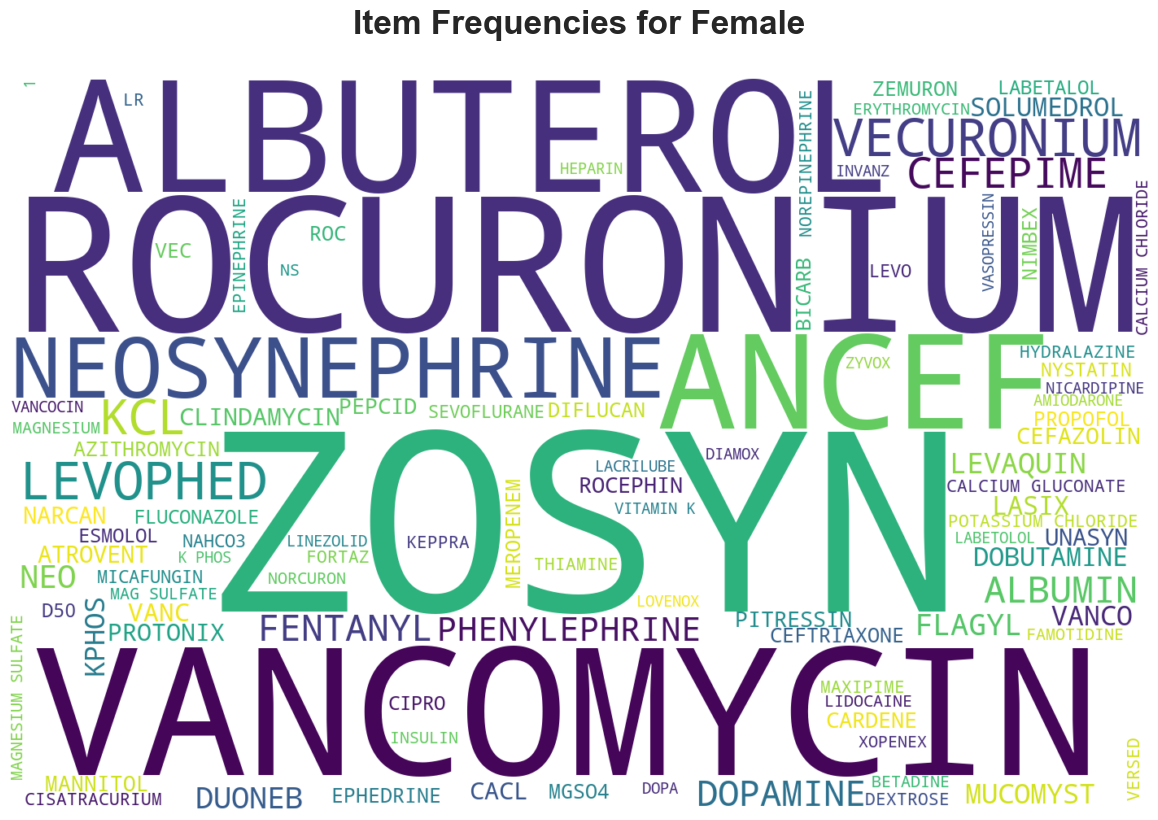

In [17]:
plot.plot_item_wordcloud(df_f.Meds_DON, title="Item Frequencies for Female", bg_color="white")

## IschemicTimeHour
* [Determining optimal donor heart ischemic times in adult cardiac transplantation](https://onlinelibrary.wiley.com/doi/full/10.1111/jocs.16558)
* [IschemicTimeHour](https://www.jhltonline.org/article/S1053-2498(23)01819-3/fulltext)
-  The maximum time it can be without a blood supply before significant damage occurs is around 4 hours when preserved in cold storage for transplantation; exceeding this timeframe significantly increases the risk of complications and poor outcomes after transplant. 

In [18]:
def plot_histogram(data, column, bins=30, txt='', title_font=20, tick_font=10, KDE=True):
    """
    Plotting histograms of multiple columns in a single figure. 
    """
    plt.figure(figsize=(10, 6))  # width, height in inches
    # plot
    ax = sns.histplot(
        data=data,
        x=column,
        kde=KDE,
        bins=bins
    )
    # aesthetics
    plt.title(f"{txt}", fontsize=title_font)
    plt.ylabel("Frequency", fontsize=tick_font, fontweight='bold')
    plt.xlabel(column, fontsize=tick_font, fontweight='bold')
    plt.tight_layout()
    plt.show()

### Male

In [19]:
# info
features = u.get_feature_info(df, 'IschemicTimeHour_DON', cat=False)

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  30082.0  3.231294  1.068969  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    216 



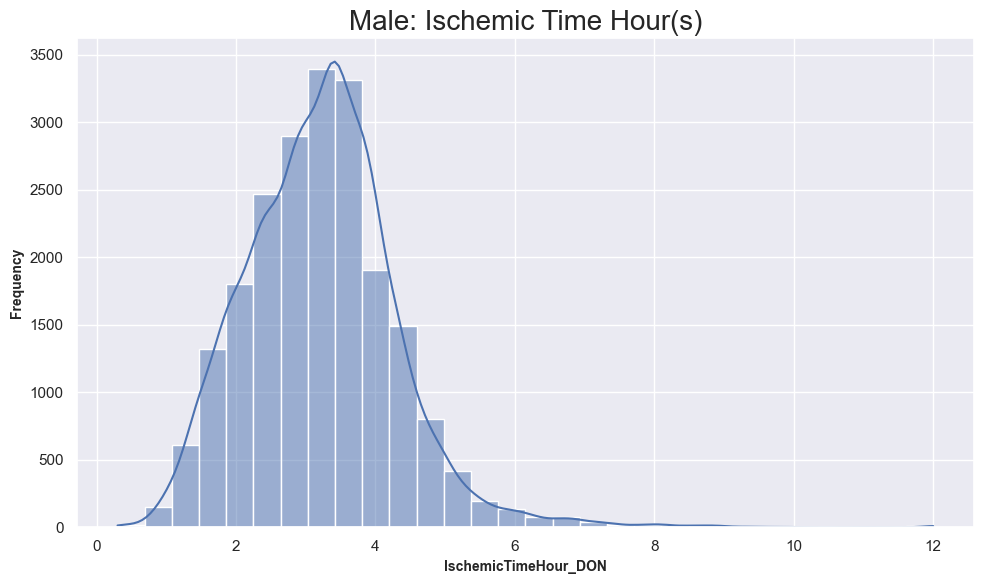

In [20]:
plot_histogram(df_m, features[0], txt='Male: Ischemic Time Hour(s)', bins=30)

In [21]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): IschemicTimeHour_DON ---
Group Sizes:    (Unknown=165, Known=21,200)
Mean survival:  (Unknown=1,308.1d, Known=1,431.4d)
Difference:     -123.3 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2365
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.1067 (Negligible)
95% CI:        [-0.2598, 0.0465]
Result: Likely Random Missingness (Effect size not significant)



In [22]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

--- Value Predicts Survival (Male): IschemicTimeHour_DON ---
Pearson r=-0.109, p=1.893e-57 & Approx. Variance Explained=1.197%
Spearman r=-0.132, p=5.824e-83 & Approx. Variance Explained=1.741%



Ischemic time of the donor for male candidate exhibits a weak but statistically significant negative correlation with recipient survival (Pearson r = −0.118, Spearman r = −0.140; both p < 1e-60), explaining only 1–2% of variance. However, missing values for donor ischemic time are associated with substantially lower survival (mean difference −254 days, Welch’s t-test p = 0.0081, Cohen’s d = −0.24, 95% CI [−0.40, −0.08]), indicating that missingness is informative and likely reflects higher-risk transplant cases.

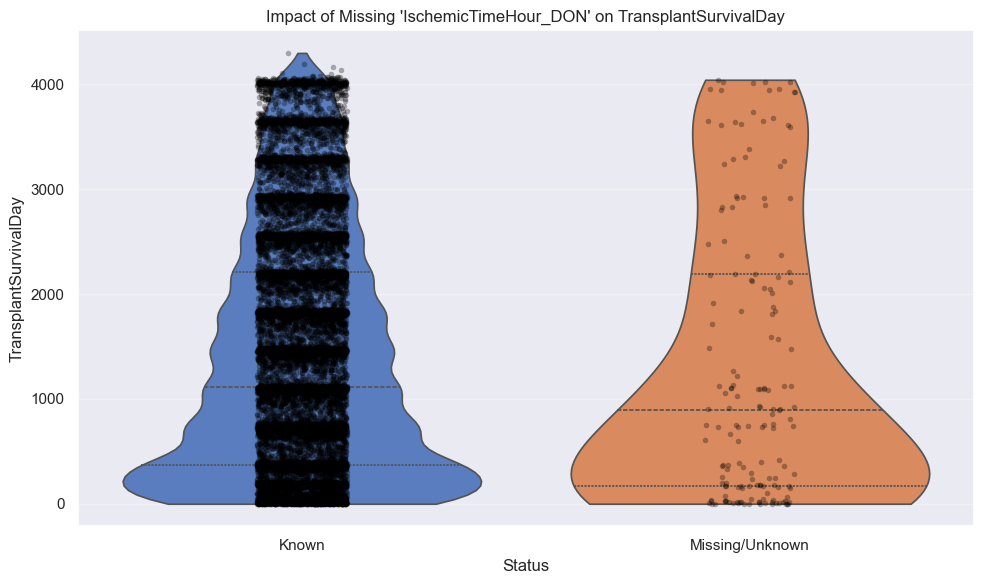

In [23]:
# plot
plot.plot_informative_missingness(df_m, features[0])

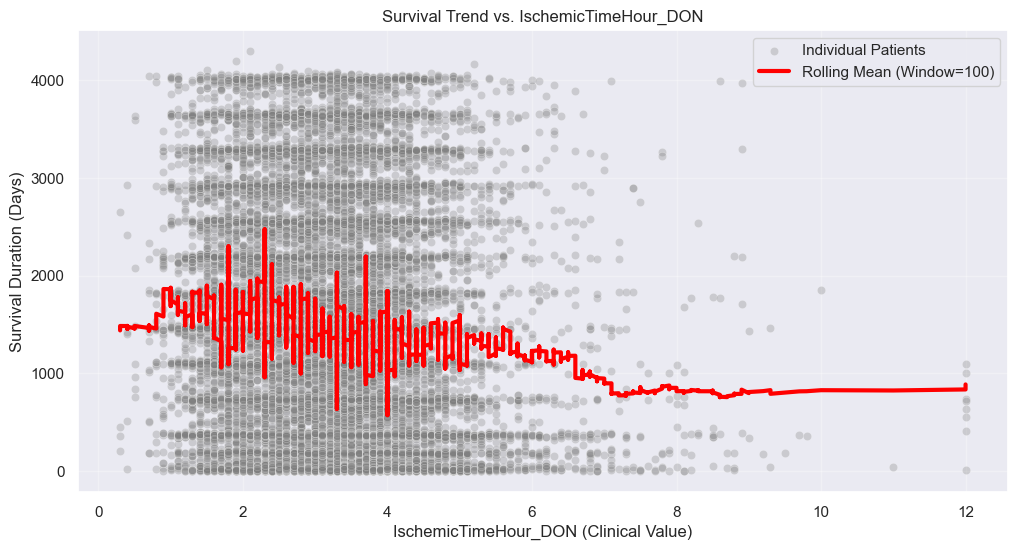

In [24]:
plot.plot_survival_trend(df_m, features[0], 'TransplantSurvivalDay', window_size=100)

### Female

In [25]:
# info
features = u.get_feature_info(df, 'IschemicTimeHour_DON', cat=False)

                        count      mean       std  min  25%  50%  75%   max
IschemicTimeHour_DON  30082.0  3.231294  1.068969  0.3  2.5  3.2  3.9  12.0

:::: NaN Count:
IschemicTimeHour_DON    216 



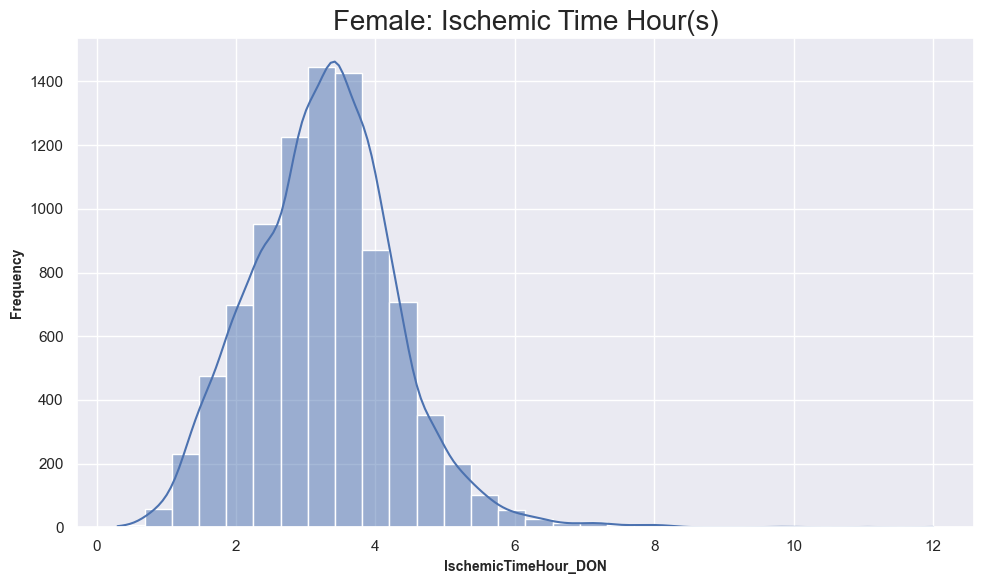

In [26]:
plot_histogram(df_f, features[0], txt='Female: Ischemic Time Hour(s)', bins=30)

In [27]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): IschemicTimeHour_DON ---
Group Sizes:    (Unknown=51, Known=8,882)
Mean survival:  (Unknown=1,110.3d, Known=1,441.7d)
Difference:     -331.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0529
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.2870 (Small)
95% CI:        [-0.5623, -0.0117]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [28]:
u.continuous_value_predicts_survival(df_f,  features[0], txt='Female')

--- Value Predicts Survival (Female): IschemicTimeHour_DON ---
Pearson r=-0.047, p=7.61e-06 & Approx. Variance Explained=0.225%
Spearman r=-0.053, p=5.295e-07 & Approx. Variance Explained=0.283%



The result for the Female subgroup is even more striking than the previous analysis. While Cohen's $d$ is still categorized as "Small" (verging on "Medium"), the actual clinical impact is massive due to a loss of 332 days of survival.

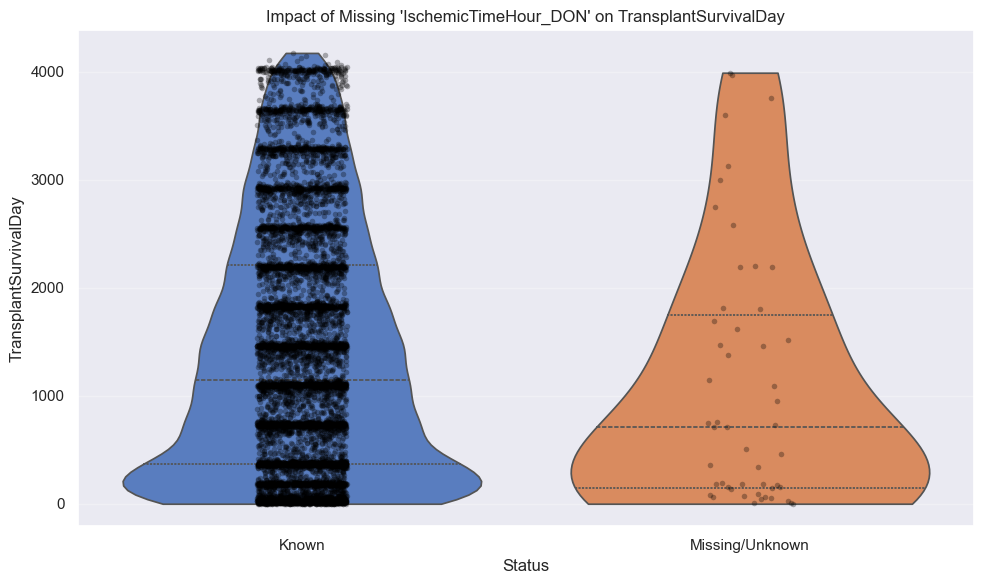

In [29]:
# plot
plot.plot_informative_missingness(df_f,  features[0])

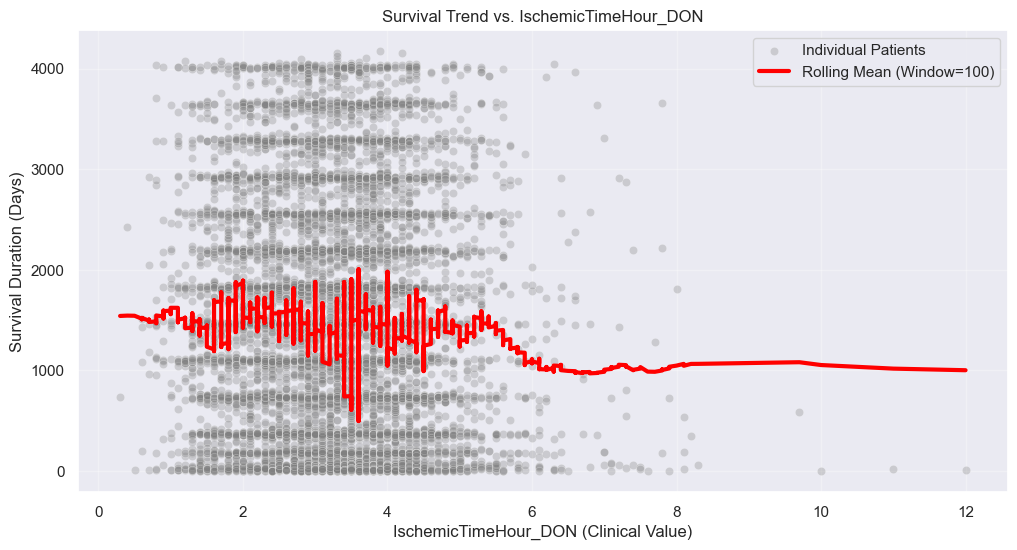

In [30]:
plot.plot_survival_trend(df_f,  features[0], 'TransplantSurvivalDay', window_size=100)

### The "Shadow Variable" (Indicator) + Median Imputation

In [31]:
# Create the binary flag for female ONLY
df_f['IschemicTime_IsMissing'] = df_f[ features[0]].isna().astype(int)

# Fill the original NaN with the median
df_m[ features[0]] = df_m[ features[0]].fillna(df_m[ features[0]].median())
df_f[ features[0]] = df_f[ features[0]].fillna(df_f[ features[0]].median())

In [32]:
# sanity check
df_f.IschemicTime_IsMissing.sum()

np.int64(51)

## PO2 & P02/FI02
* The UNOS dataset variables LungPO2_DON (donor partial pressure of oxygen) and LungPO2_FIO2_DON (donor fraction of inspired oxygen) are critical donor lung quality metrics used to calculate the ratio. These metrics help assess pulmonary function and graft suitability. They are crucial in assessing early graft function and donor risk.
* [Lung PCO2](https://www.ncbi.nlm.nih.gov/books/NBK551648/) (Partial Pressure of Carbon Dioxide)
* A blood gas test is performed to measure the amount of C02 in the blood. When the lung’s ability to exchange oxygen and CO2 becomes impaired, the PCO2 level may increase. The candidate’s current PC02 and change in PC02 are both considered in the lung allocation score calculation to reflect worsening PC02 values. PCO2 is used in the Lung Allocation Score.
* The normal range for the partial pressure of carbon dioxide (PCO2) in arterial blood is typically between 35 and 45 mmHg
* Based on current clinical literature, the assertion that "no sex-specific thresholds exist" is largely true for routine clinical practice, despite evidence that biological sex influences $CO_2$ perception and physiological levels.  

In [33]:
# info
features = u.get_feature_info(df_m, 'LungPO2_DON|LungPO2_FIO2_DON', cat=False)

                    count        mean         std   min    25%    50%    75%    max
LungPO2_DON       21286.0  277.791314  159.238586  7.38  129.8  247.6  422.0  700.0
LungPO2_FIO2_DON  21234.0   82.237685   25.424157  1.00   60.0  100.0  100.0  100.0

:::: NaN Count:
LungPO2_DON          79
LungPO2_FIO2_DON    131 



### Male

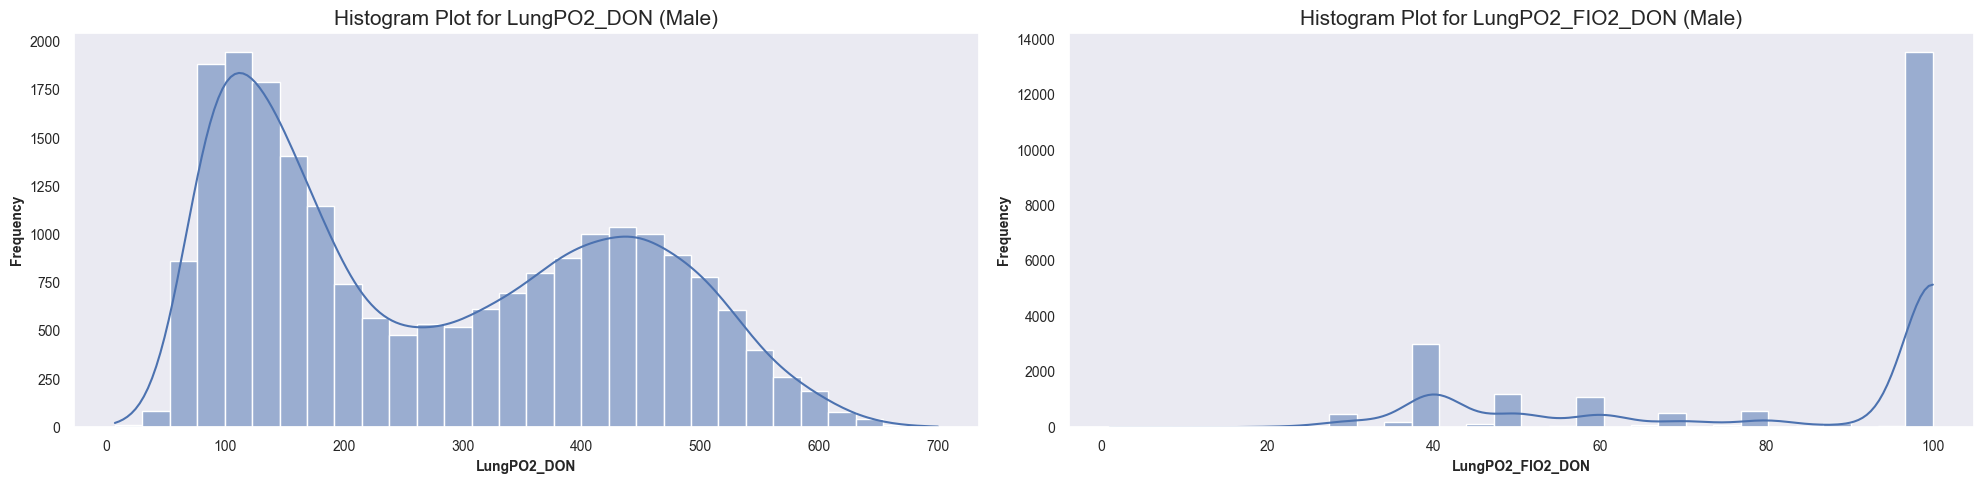

In [34]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

### Female

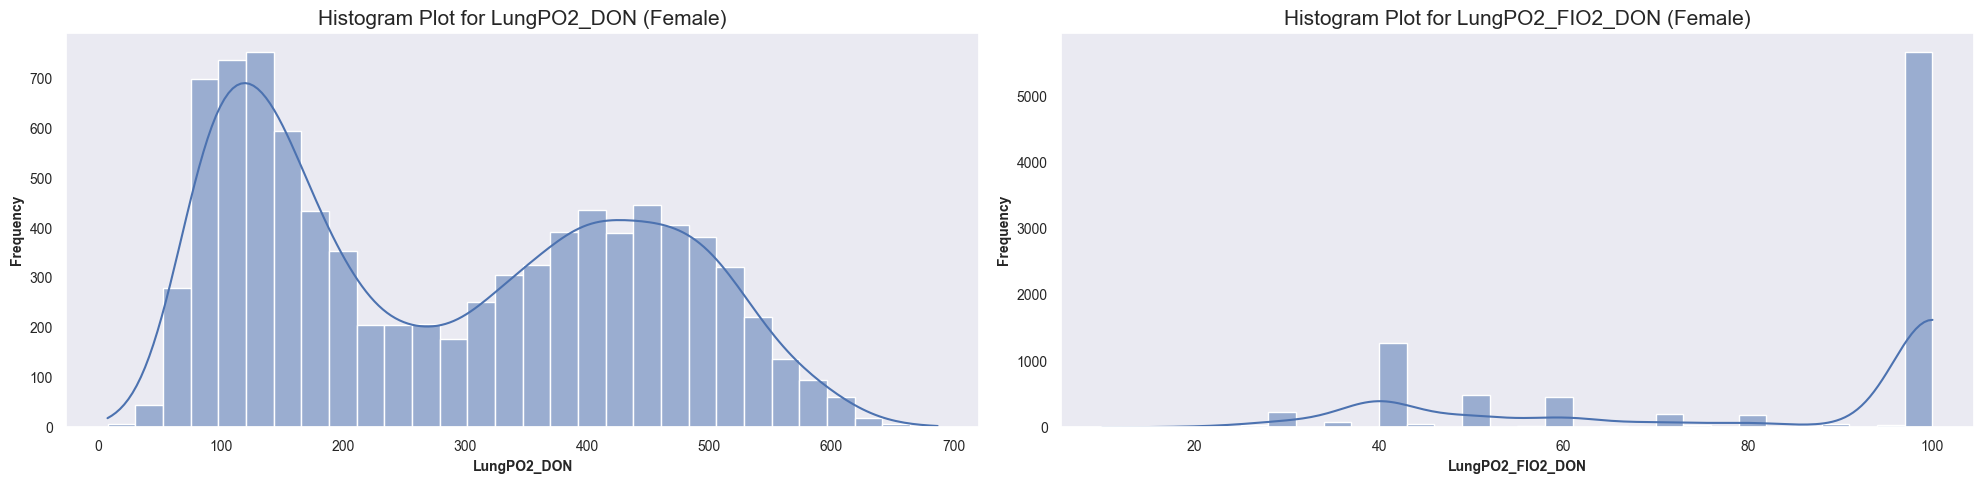

In [35]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

#### The "Shadow Variable" (Indicator)

In [36]:
# create new missingness features
for feature in features:
    df_m[feature + '_IsMissing'] = df_m[feature].isna().astype(int)
    df_f[feature + '_IsMissing'] = df_f[feature].isna().astype(int)

#### Median

In [37]:
# impute median for LungPO2_FIO2_DON ONLY
df_m['LungPO2_FIO2_DON'] = df_m.LungPO2_FIO2_DON.fillna(df_m.LungPO2_FIO2_DON.median())
df_f['LungPO2_FIO2_DON'] = df_f.LungPO2_FIO2_DON.fillna(df_f.LungPO2_FIO2_DON.median())

#### Use GMM sampling to preserve the bimodal geometry

##### User Function(s)

In [38]:
from sklearn.mixture import GaussianMixture
from scipy.stats import entropy



def gmm_sample(model, n, random_state=None):
    """
    Draws n samples from a fitted GaussianMixture model using modern NumPy RNG.
    
    Parameters:
    -----------
    model : GaussianMixture (A fitted sklearn GMM model)
    n : int
        Number of samples to draw.
    random_state : int, np.random.Generator, or None
        Seed or Generator for reproducibility.
    """
    # Initialize the modern Generator
    rng = np.random.default_rng(random_state)
    
    # Choose component indices according to mixture weights
    comp = rng.choice(
        model.weights_.size,
        size=n,
        p=model.weights_
    )
    
    # Extract means and variances using .ravel() for efficiency
    # .ravel() provides a view rather than a copy
    means = model.means_.ravel()
    covs = model.covariances_.ravel()
    
    # Sample using the Generator's normal method
    # loc and scale accept arrays, allowing for vectorized sampling
    return rng.normal(
        loc=means[comp],
        scale=np.sqrt(covs[comp])
    )


def gmm_full_diagnostic(data, n_components=2, init_params='kmeans', n_init=10, 
                        n=10_000, random_state=SEED, title_suffix=""):
    """
    Fits a GMM, generates synthetic samples, calculates KL Divergence, 
    and plots the result for a complete data science validation.
    """
    # Prep Data: Convert Series to NumPy and handle dimensions
    if isinstance(data, pd.Series):
        data = data.dropna().values
        
    X = data.reshape(-1, 1) if data.ndim == 1 else data
    
    # Fit Model
    model = GaussianMixture(
        n_components=n_components, 
        covariance_type="full",    # capturing complex relationships
        init_params=init_params,   # how the starting parameters of the GMM are chosen
        n_init=n_init,             # run GMM X times each time with a different random initialization 
                                   # keep the best model (highest log-likelihood)
        random_state=random_state
    ).fit(X)

    # Initialize the modern generator
    rng = np.random.default_rng(random_state)
    
    # Select components based on weights
    comp_idx = rng.choice(model.weights_.size, size=n, p=model.weights_)
    means = model.means_.flatten()
    stds = np.sqrt(model.covariances_.flatten())
    X_synth = np.random.normal(means[comp_idx], stds[comp_idx])
    
    # Calculate KL Divergence (Discretized)
    common_range = (min(X.min(), X_synth.min()), max(X.max(), X_synth.max()))
    p_hist, _ = np.histogram(X, bins=50, range=common_range, density=True)
    q_hist, _ = np.histogram(X_synth, bins=50, range=common_range, density=True)
    kl_score = entropy(p_hist + 1e-10, q_hist + 1e-10)
    
    # Visualization
    plt.figure(figsize=(12, 6))
    sns.kdeplot(X.flatten(), label='Real Data', fill=True, color='royalblue', alpha=0.4)
    sns.kdeplot(X_synth, label=f'GMM (n={n_components})', fill=True, color='darkorange', alpha=0.3)

    # Formatting
    plt.title(f"GMM Validation: {model.n_components} Components {title_suffix}\n"
              f"KL Divergence: {kl_score:.4f} | BIC: {model.bic(X_synth.reshape(-1,1)):.2f}")
    plt.xlabel(title_suffix)
    plt.ylabel("Density")
    plt.grid(axis='y', linestyle='--', alpha=0.7)
    plt.legend()
    plt.show()
    
    return model, kl_score


def optimize_gmm_components(data, max_components=10, 
                            init_params='kmeans', 
                            n_init=10, 
                            random_state=SEED, 
                            n_samples=10_000,
                            bins=30):
    """
    Sweeps through n_components to find the optimal GMM fit based on BIC and KL Divergence.
    
    Returns:
        results_df: DataFrame containing n, BIC, and KL scores.
        best_model: The GaussianMixture object with the lowest KL Divergence.
    """
    # initialize variables
    results = []
    best_kl = float('inf')
    best_model = None

    # Prep Data: Convert Series to NumPy and handle dimensions
    if isinstance(data, pd.Series):
        data = data.dropna().values
    
    # Ensure data is 2D for sklearn (N, 1)
    X = data.reshape(-1, 1) if data.ndim == 1 else data
    
    print(f"{'n':>3} | {'BIC':>12} | {'KL Div':>8}")
    print("-" * 30)

    # iterate components
    for n in range(1, max_components + 1):
        # n_init=n_init provides stability against local optima
        gm = GaussianMixture(
            n_components=n, 
            covariance_type="full",
            init_params=init_params,
            n_init=n_init, 
            random_state=random_state
        ).fit(X)
        
        # Calculate KL using the function we built
        kl = calculate_gmm_kl_divergence(gm, X.flatten(), n_samples, random_state, bins)
        bic = gm.bic(X)
        
        results.append({
            'n_components': n,
            'bic': bic,
            'kl_divergence': kl
        })
        
        print(f"{n:3d} | {bic:12.2f} | {kl:8.4f}")
        
        # Track the best performing model based on KL
        if kl < best_kl:
            best_kl = kl
            best_model = gm
            
    return pd.DataFrame(results), best_model
    

def calculate_gmm_kl_divergence(model, real_data, n_samples, random_state, bins):
    """
    Estimates the KL Divergence between the real data distribution and 
    the GMM generative model.
    
    Parameters:
    -----------
    model : GaussianMixture object
        The fitted GMM.
    real_data : array-like
        The original observations (e.g., Lung P/F ratios).
    n_samples : int
        Number of synthetic samples to generate for the estimation.
    bins : int
        Number of bins for discretizing the distributions.
        
    Returns:
    --------
    kl_dist : float
        The KL Divergence score (lower is better).
    """
    # Generate synthetic data using a custom sampler
    synth_data = gmm_sample(model, n_samples, random_state)
    
    # Define a common range for binning to ensure alignment
    data_min = min(real_data.min(), synth_data.min())
    data_max = max(real_data.max(), synth_data.max())
    common_range = (data_min, data_max)
    
    # Calculate histograms (PDFs)
    # Add a tiny epsilon (1e-10) to avoid division by zero or log(0)
    p_hist, _ = np.histogram(real_data, bins=bins, range=common_range, density=True)
    q_hist, _ = np.histogram(synth_data, bins=bins, range=common_range, density=True)
    # tiny epsilon
    p_prob = p_hist + 1e-10
    q_prob = q_hist + 1e-10
    
    # Compute KL Divergence (P || Q)
    # entropy(pk, qk) computes S = sum(pk * log(pk / qk))
    kl_dist = entropy(p_prob, q_prob)
    
    return kl_dist
    

def gmm_impute(
    data,
    col,
    model,
    mode="clustering",
    random_state=SEED,
    clip_min=None,
    clip_max=None,
    return_mask=False
):
    """
    Impute missing values in a 1D numeric column using a fitted GaussianMixture.

    mode="clustering":
        Sample from the fitted marginal mixture distribution.

    mode="modeling":
        Fill missing values with the mixture mean.
    """
    # Validations
    if col not in data.columns:
        raise KeyError(f"Column '{col}' not found in DataFrame.")
    if mode not in {"clustering", "modeling"}:
        raise ValueError("mode must be 'clustering' or 'modeling'")
    if not hasattr(model, "means_") or not hasattr(model, "weights_"):
        raise ValueError("model must be a fitted sklearn.mixture.GaussianMixture object.")
    if getattr(model, "means_", None) is None or model.means_.ndim != 2 or model.means_.shape[1] != 1:
        raise ValueError("This function is intended for a univariate GMM fit on one numeric column.")

    # Work on a copy to avoid mutating
    out = data.copy()
    mask = out[col].isna()
    n_missing = int(mask.sum())

    # Nothing to impute
    if n_missing == 0:
        return (out, mask) if return_mask else out

    # array of means & weights and collapse it into a simple 1D list
    means = model.means_.ravel()
    weights = model.weights_.ravel()
    rng = np.random.default_rng(random_state) # sets a global state (stays local to the variable)

    if mode == "clustering":
        comp = rng.choice(model.n_components, size=n_missing, p=weights)

        ct = model.covariance_type
        if ct == "full":
            variances = np.array([model.covariances_[k][0, 0] for k in range(model.n_components)])
        elif ct == "tied":
            variances = np.repeat(model.covariances_[0, 0], model.n_components)
        elif ct in {"diag", "spherical"}:
            variances = np.asarray(model.covariances_).ravel()
        else:
            raise ValueError(f"Unsupported covariance_type: {ct}")

        sampled = rng.normal(loc=means[comp], scale=np.sqrt(variances[comp]))

        if clip_min is not None or clip_max is not None:
            sampled = np.clip(
                sampled,
                clip_min if clip_min is not None else -np.inf,
                clip_max if clip_max is not None else np.inf,
            )

        out.loc[mask, col] = sampled

    else:
        imputed_value = float(np.dot(means, weights))
        if clip_min is not None or clip_max is not None:
            imputed_value = float(np.clip(
                imputed_value,
                clip_min if clip_min is not None else -np.inf,
                clip_max if clip_max is not None else np.inf,
            ))
        out[col] = out[col].fillna(imputed_value)

    return (out, mask) if return_mask else out


#### Impute (LungPO2_FIO2_DON)

##### Male

In [39]:
# optimize
results, best_model = optimize_gmm_components(df_m['LungPO2_DON'], max_components=10, n_init=5, random_state=SEED)
# display
print(results)

  n |          BIC |   KL Div
------------------------------
  1 |    276283.21 |   0.2546
  2 |    266105.86 |   0.0296
  3 |    265802.99 |   0.0220
  4 |    265373.81 |   0.0116
  5 |    265207.05 |   0.0060
  6 |    265154.47 |   0.0095
  7 |    265152.88 |   0.0081
  8 |    265158.20 |   0.0063
  9 |    265161.39 |   0.0038
 10 |    265223.94 |   0.0062
   n_components            bic  kl_divergence
0             1  276283.205569       0.254584
1             2  266105.861726       0.029598
2             3  265802.988807       0.021987
3             4  265373.813552       0.011611
4             5  265207.053496       0.005975
5             6  265154.468884       0.009457
6             7  265152.876664       0.008125
7             8  265158.202819       0.006294
8             9  265161.392493       0.003796
9            10  265223.938347       0.006156


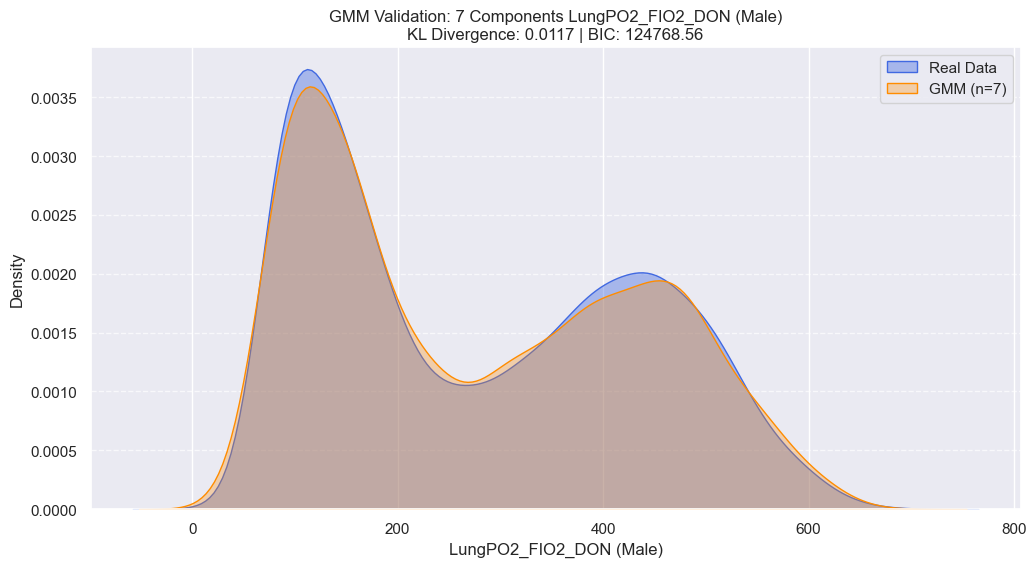

In [40]:
# validate
gmm_m, kl_m = gmm_full_diagnostic(df_m['LungPO2_DON'], n_components=7, n_init=10, title_suffix="LungPO2_FIO2_DON (Male)")

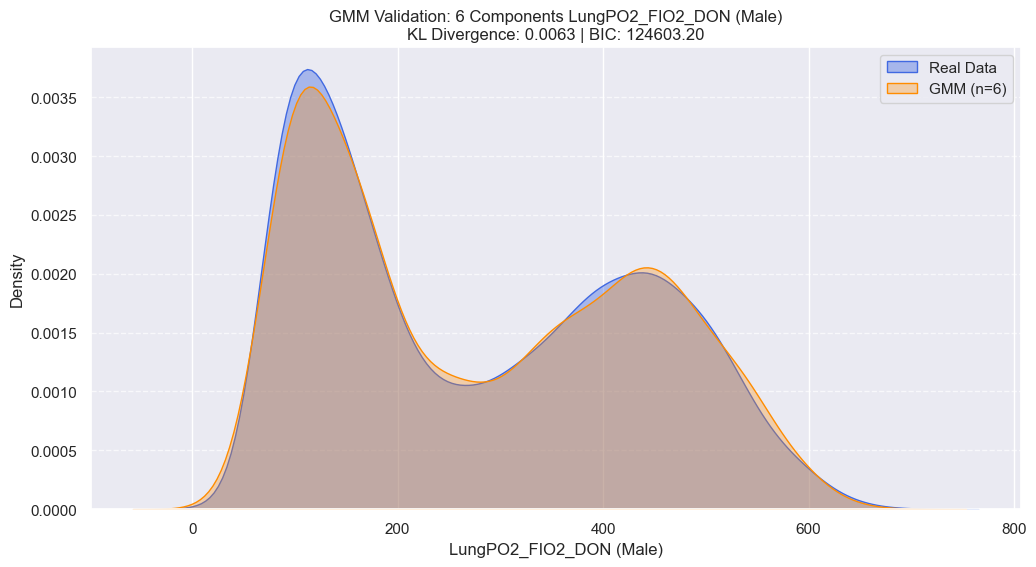

In [41]:
# validate
gmm_m, kl_m = gmm_full_diagnostic(df_m['LungPO2_DON'], n_components=6, n_init=10, title_suffix="LungPO2_FIO2_DON (Male)")

##### Female

In [42]:
# optimize
results, best_model = optimize_gmm_components(df_f['LungPO2_DON'], max_components=10, n_init=5, random_state=SEED)
# display
print(results)

  n |          BIC |   KL Div
------------------------------
  1 |    115647.28 |   0.2507
  2 |    111475.86 |   0.0247
  3 |    111387.35 |   0.0186
  4 |    111230.81 |   0.0082
  5 |    111226.58 |   0.0066
  6 |    111226.73 |   0.0068
  7 |    111232.35 |   0.0054
  8 |    111238.92 |   0.0043
  9 |    111259.58 |   0.0059
 10 |    111296.91 |   0.0022
   n_components            bic  kl_divergence
0             1  115647.284774       0.250744
1             2  111475.863393       0.024668
2             3  111387.351661       0.018613
3             4  111230.811436       0.008156
4             5  111226.580700       0.006647
5             6  111226.732739       0.006790
6             7  111232.350207       0.005395
7             8  111238.921627       0.004340
8             9  111259.575892       0.005929
9            10  111296.909605       0.002213


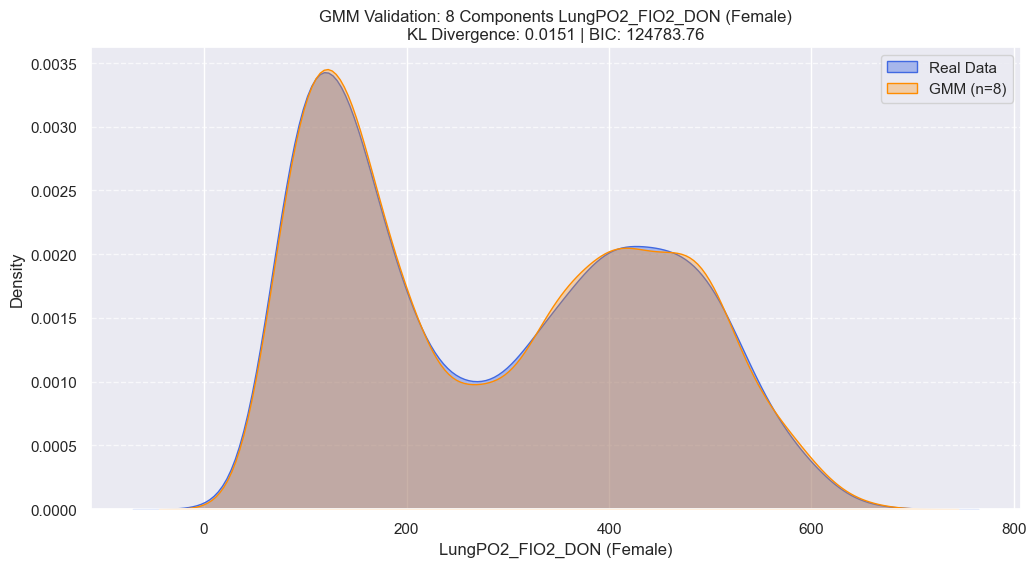

In [43]:
# validate
gmm_f, kl_f = gmm_full_diagnostic(df_f['LungPO2_DON'], n_components=8, n_init=10, title_suffix="LungPO2_FIO2_DON (Female)")

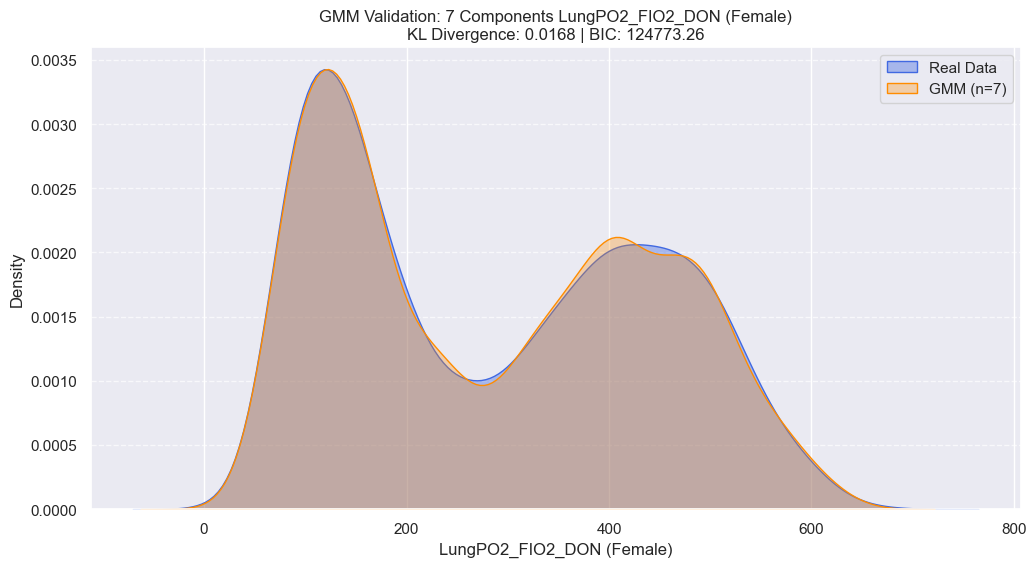

In [44]:
# validate
gmm_f, kl_f = gmm_full_diagnostic(df_f['LungPO2_DON'], n_components=7, n_init=10, title_suffix="LungPO2_FIO2_DON (Female)")

**Note:** By increasing the number of components to 6 males and 7 for females, which lowered the Bias (the model's systematic error in missing those specific sub-peaks) at the cost of slightly higher Variance (more parameters to estimate). We have enough data to support the complexity of 6 or 7 Gaussians without immediately hitting overfitting issues

##### GMM Sampling

In [45]:
# impute
df_m = gmm_impute(df_m, 'LungPO2_DON', gmm_m, mode="clustering", random_state=SEED)
df_f = gmm_impute(df_f, 'LungPO2_DON', gmm_f, mode="clustering", random_state=SEED)

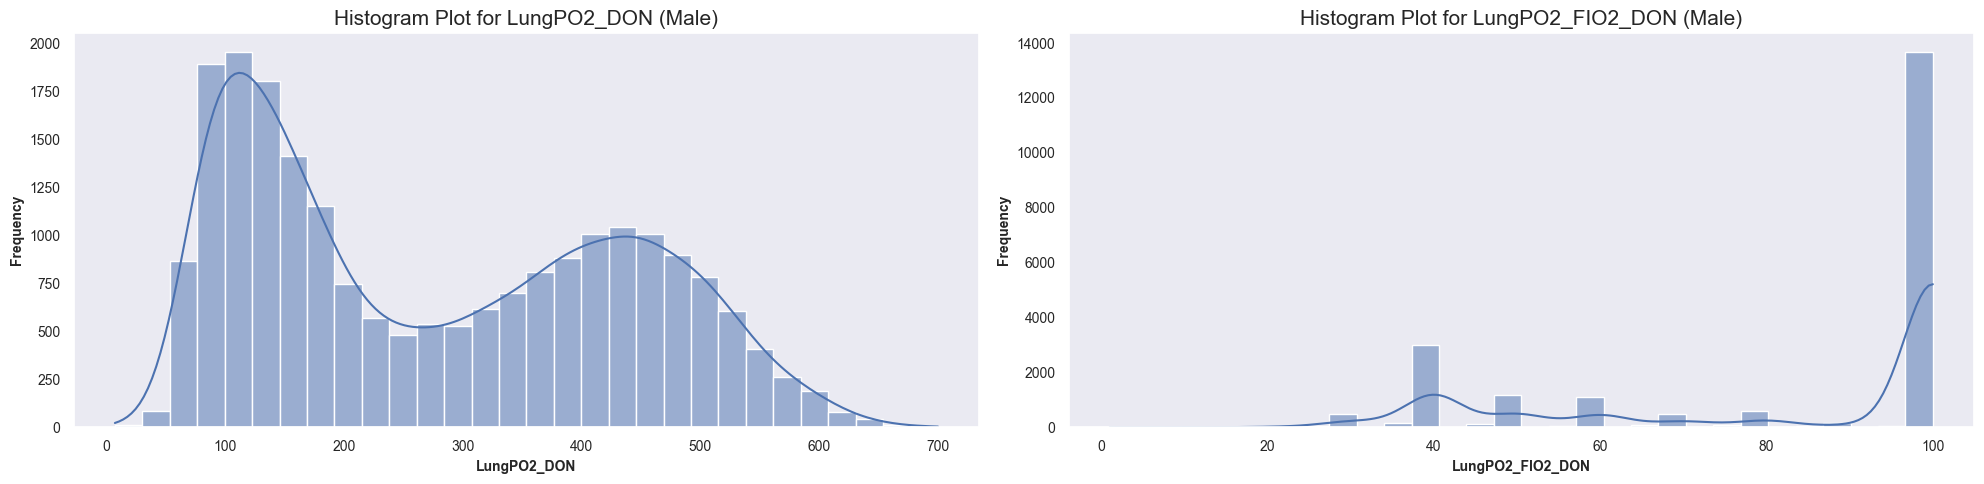

In [46]:
plot.plot_histogram(df_m, features, bins=30, txt='(Male)')

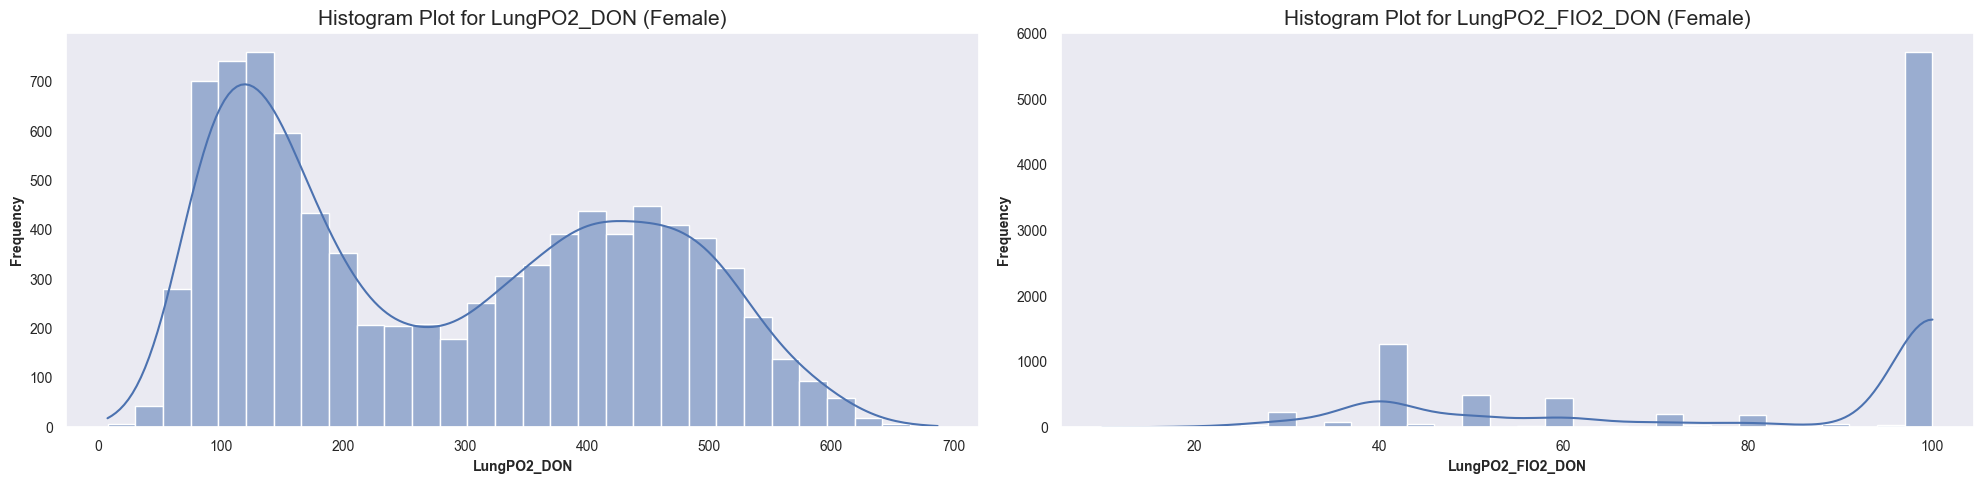

In [47]:
plot.plot_histogram(df_f, features, bins=30, txt='(Female)')

In [48]:
df_m[['LungPO2_DON', 'LungPO2_DON_IsMissing']][df_m.LungPO2_DON_IsMissing == 1].head()

,LungPO2_DON,LungPO2_DON_IsMissing
302,164.762858,1
328,90.611216,1
406,332.018914,1
472,561.025036,1
1501,670.183148,1


In [49]:
df_f[['LungPO2_DON', 'LungPO2_DON_IsMissing']][df_f.LungPO2_DON_IsMissing == 1].head()

,LungPO2_DON,LungPO2_DON_IsMissing
671,140.474234,1
1631,482.643510,1
2393,216.399589,1
3634,367.287872,1
3750,367.170477,1


## OrganRecovery_PCO2
* Research indicates that there are significant gender-based differences in physiological parameters related to organ recovery, such as peak oxygen consumption $VO_2$ (oxygen consumption) and carbon dioxide metabolism, which are often influenced by differences in hemoglobin mass, blood volume, and lung function.
* Carbon Dioxide Metabolism Differences: Studies on CO clearance have shown that females have a shorter half-time for removal, but this is largely due to lower total hemoglobin mass $(Hb_{TOT})$ and differing alveolar ventilation rates.
* End-Tidal $CO_2$ $(PETCO_2)$: Resting $PETCO_2$ (End-tidal Carbon Dioxide Pressure) has been found to be significantly higher in males than in females.
* Venous-to-Arterial $PCO_2$ Differences: While $PCO_2$ gaps are monitored to predict complications, they are often used to gauge cardiac output and tissue oxygenation, and while not consistently showing a gender difference in every study, they serve as crucial metrics to manage metabolic acidosis during recovery.
* Respiratory Limitations: Women generally have smaller lung capacities and vital capacity, resulting in lower maximal tidal volume during recovery and a greater reliance on increased respiratory rate to maintain adequate alveolar ventilation.
* Clinical Implications: These differences mean that women may reach lower $VO_2$ levels before benefiting from transplantation compared to men.

### Male

In [50]:
# info
features = u.get_feature_info(df_m, 'OrganRecovery_PCO2', cat=False)

                          count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  21305.0  38.868194  7.060265  10.1  34.3  38.0  42.5  116.3

:::: NaN Count:
OrganRecovery_PCO2_DON    60 



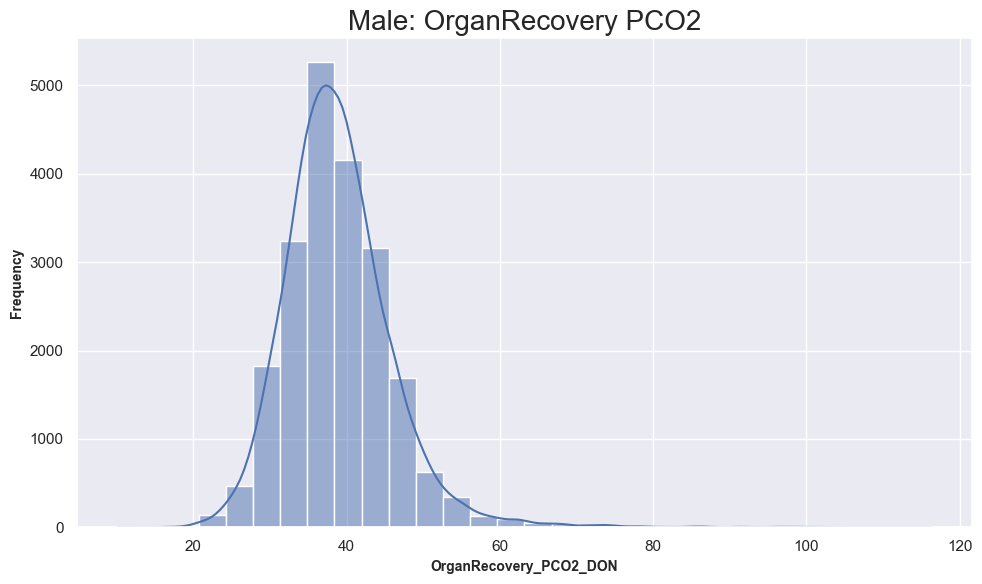

In [51]:
plot_histogram(df_m, features[0], txt='Male: OrganRecovery PCO2', bins=30)

In [52]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): OrganRecovery_PCO2_DON ---
Group Sizes:    (Unknown=60, Known=21,305)
Mean survival:  (Unknown=863.4d, Known=1,432.1d)
Difference:     -568.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.4920 (Small)
95% CI:        [-0.7454, -0.2386]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [53]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

--- Value Predicts Survival (Male): OrganRecovery_PCO2_DON ---
Pearson r=-0.092, p=3.805e-41 & Approx. Variance Explained=0.844%
Spearman r=-0.093, p=1.529e-42 & Approx. Variance Explained=0.873%



The primary clinical signal for donor $PCO_2$ lies not in its measured value, which shows a negligible association with survival ($r \approx -0.085$), but in its missingness. Missing $PCO_2$ data was associated with a clinically significant 517-day survival penalty and a moderate effect size ($d \approx -0.49$). This suggests that the lack of a recorded value serves as a proxy for unobserved high-risk scenarios, capturing informative risk that remains `hidden` in the analysis.

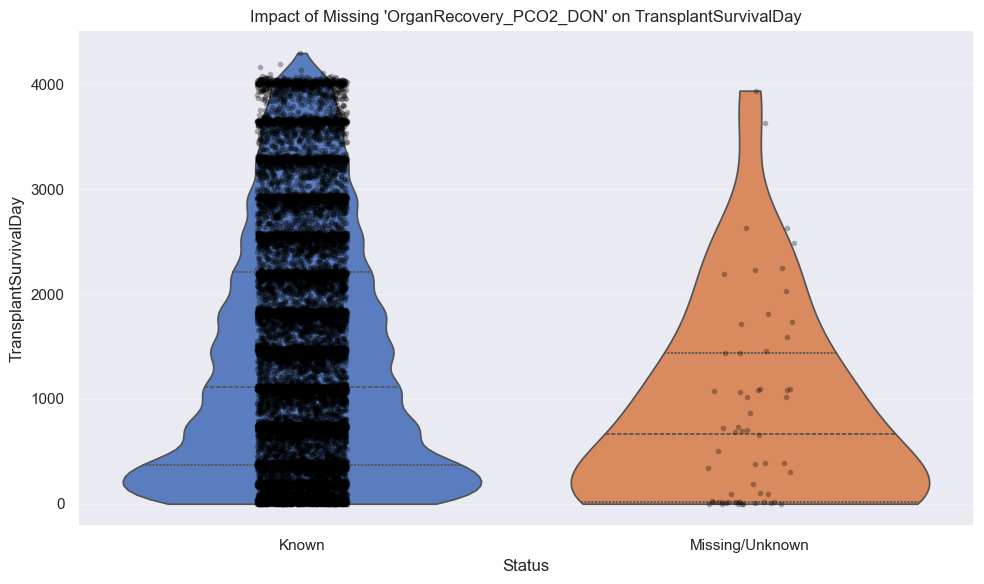

In [54]:
# plot
plot.plot_informative_missingness(df_m, features[0])

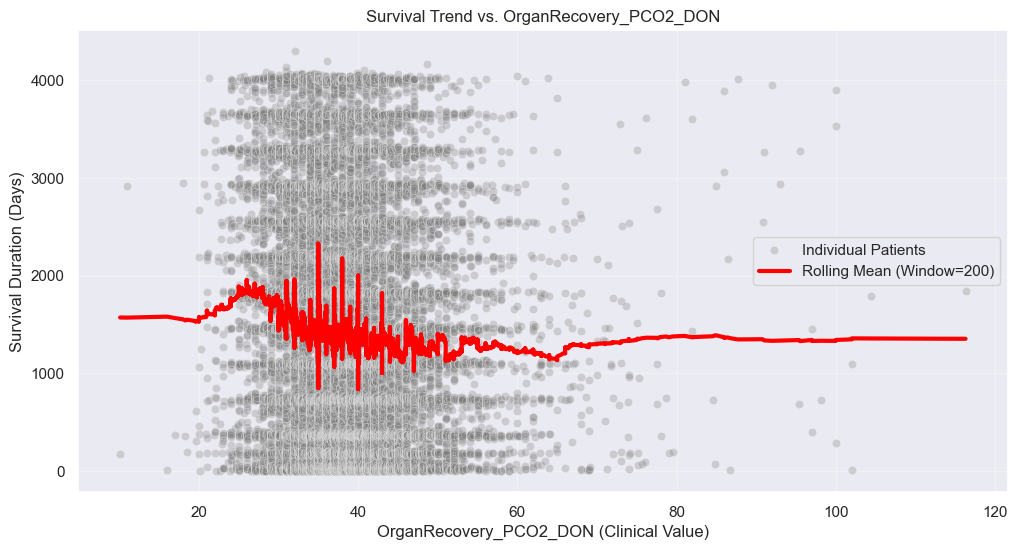

In [55]:
plot.plot_survival_trend(df_m, features[0], 'TransplantSurvivalDay', window_size=200)

### Female

In [56]:
# info
features = u.get_feature_info(df_f, 'OrganRecovery_PCO2', cat=False)

                         count       mean       std   min   25%   50%   75%    max
OrganRecovery_PCO2_DON  8910.0  37.603657  7.084903  15.0  33.0  37.0  41.1  108.0

:::: NaN Count:
OrganRecovery_PCO2_DON    23 



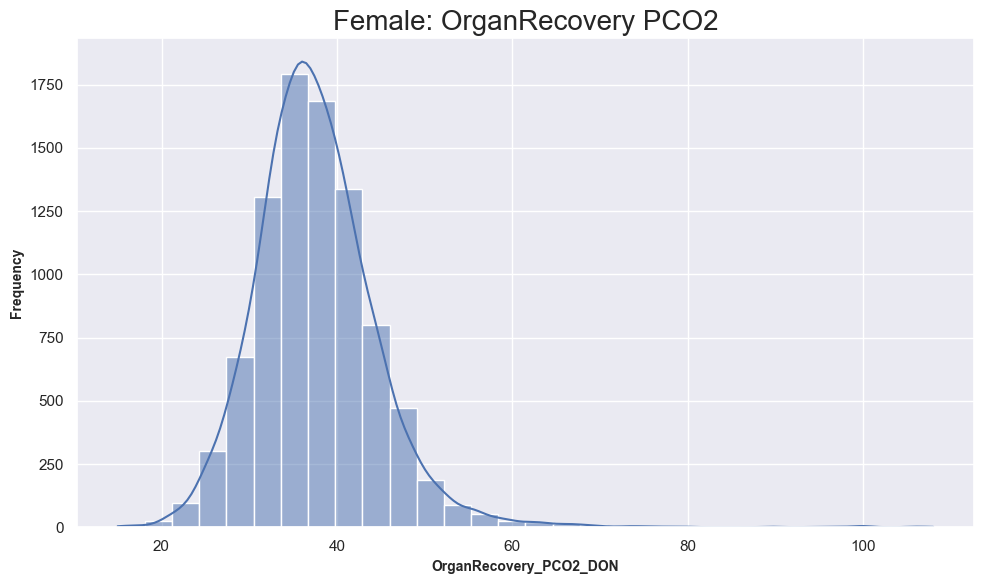

In [57]:
plot_histogram(df_f, features[0], txt='Female: OrganRecovery PCO2', bins=30)

In [58]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): OrganRecovery_PCO2_DON ---
Group Sizes:    (Unknown=23, Known=8,910)
Mean survival:  (Unknown=991.8d, Known=1,441.0d)
Difference:     -449.2 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0398
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.3889 (Small)
95% CI:        [-0.7982, 0.0203]
Result: Likely Random Missingness (Effect size not significant)



In [59]:
u.continuous_value_predicts_survival(df_f, features[0], txt='Female')

--- Value Predicts Survival (Female): OrganRecovery_PCO2_DON ---
Pearson r=-0.097, p=5.781e-20 & Approx. Variance Explained=0.935%
Spearman r=-0.105, p=4.413e-23 & Approx. Variance Explained=1.093%



Missing donor $PCO_2$ was associated with reduced survival in both males and females; however, statistical significance was observed only in males. In females, the effect was similar in direction but did not reach significance, likely due to limited sample size (n=23 missing cases), resulting in wide confidence intervals.

### The "Shadow Variable" (Indicator) + Median Imputation

In [60]:
# Create the binary flag
df_m['OrganRecovery_PCO2_IsMissing'] = df_m[features[0]].isna().astype(int)
df_f['OrganRecovery_PCO2_IsMissing'] = df_f[features[0]].isna().astype(int)

# Fill the original NaN with the median
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].median())
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].median())
# sanity check
df_m.OrganRecovery_PCO2_IsMissing.sum(), df_f.OrganRecovery_PCO2_IsMissing.sum()

(np.int64(60), np.int64(23))

## BloodPH
* There are minor, statistically significant differences in blood pH levels between genders, though both fall within the normal range of 7.35 to 7.45. Research indicates that females tend to have a slightly higher arterial blood pH (more basic) and lower partial pressure of carbon dioxide $(PaCO_2)$ compared to males.
* The subtle differences in blood pH between genders are likely due to a combination of hormonal (estrogen), genetic (X chromosome), and physiological factors, such as differences in metabolism and respiration.

### Male

In [61]:
# info
features = u.get_feature_info(df_m, 'BloodPH', cat=False)

               count      mean       std  min   25%   50%   75%   max
BloodPH_DON  21308.0  7.415916  0.074967  5.0  7.38  7.42  7.46  7.93

:::: NaN Count:
BloodPH_DON    57 



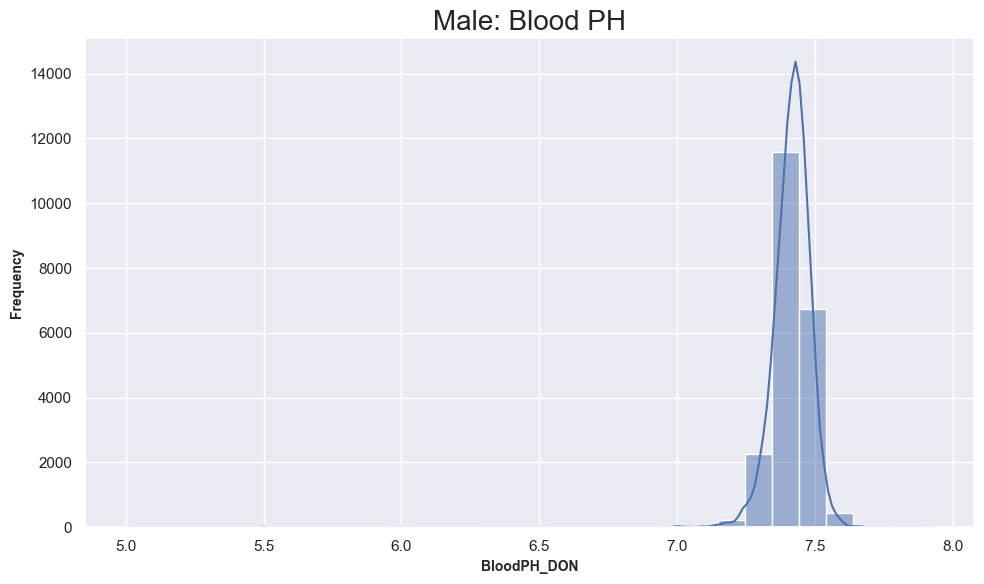

In [62]:
plot_histogram(df_m, features[0], txt='Male: Blood PH', bins=30)

In [63]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): BloodPH_DON ---
Group Sizes:    (Unknown=57, Known=21,308)
Mean survival:  (Unknown=846.2d, Known=1,432.0d)
Difference:     -585.8 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0000
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.5068 (Medium)
95% CI:        [-0.7668, -0.2468]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



In [64]:
u.continuous_value_predicts_survival(df_m, features[0], txt='Male')

--- Value Predicts Survival (Male): BloodPH_DON ---
Pearson r=-0.025, p=0.0002645 & Approx. Variance Explained=0.062%
Spearman r=-0.026, p=0.0001947 & Approx. Variance Explained=0.065%



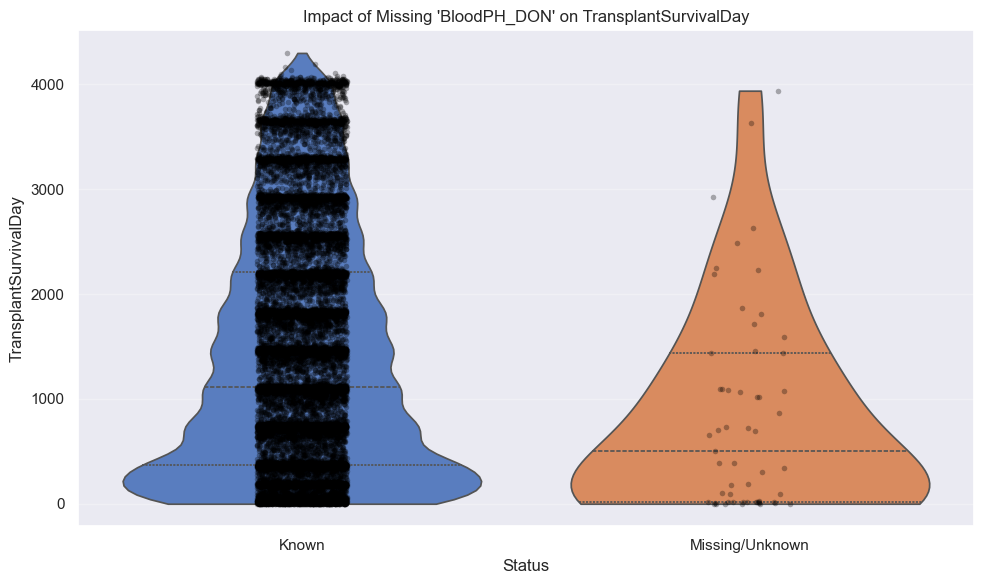

In [65]:
# plot
plot.plot_informative_missingness(df_m, features[0])

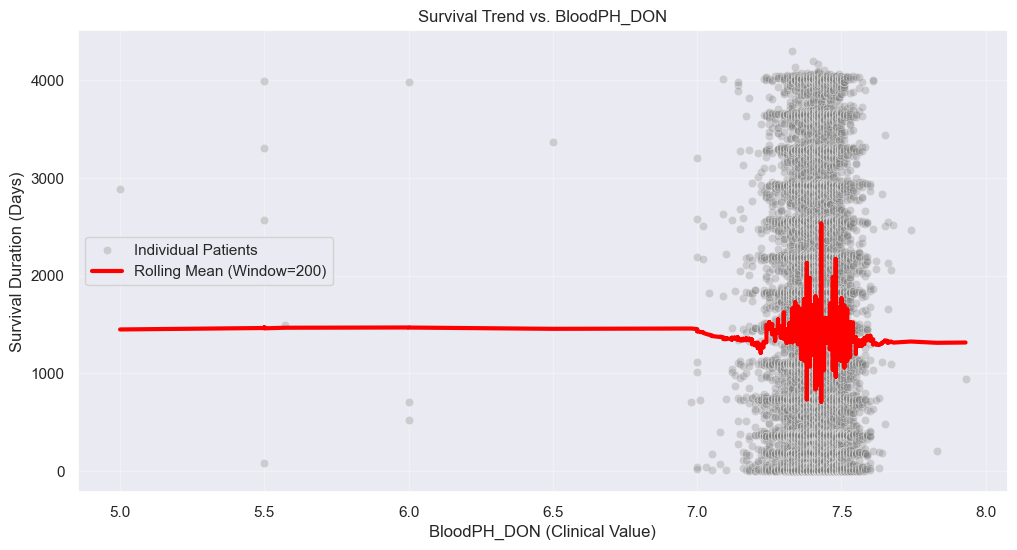

In [66]:
plot.plot_survival_trend(df_m, features[0], 'TransplantSurvivalDay', window_size=200)

### Female

In [67]:
# info
features = u.get_feature_info(df_f, 'BloodPH', cat=False)

              count      mean       std  min   25%   50%   75%   max
BloodPH_DON  8913.0  7.415252  0.079365  5.0  7.38  7.42  7.46  7.82

:::: NaN Count:
BloodPH_DON    20 



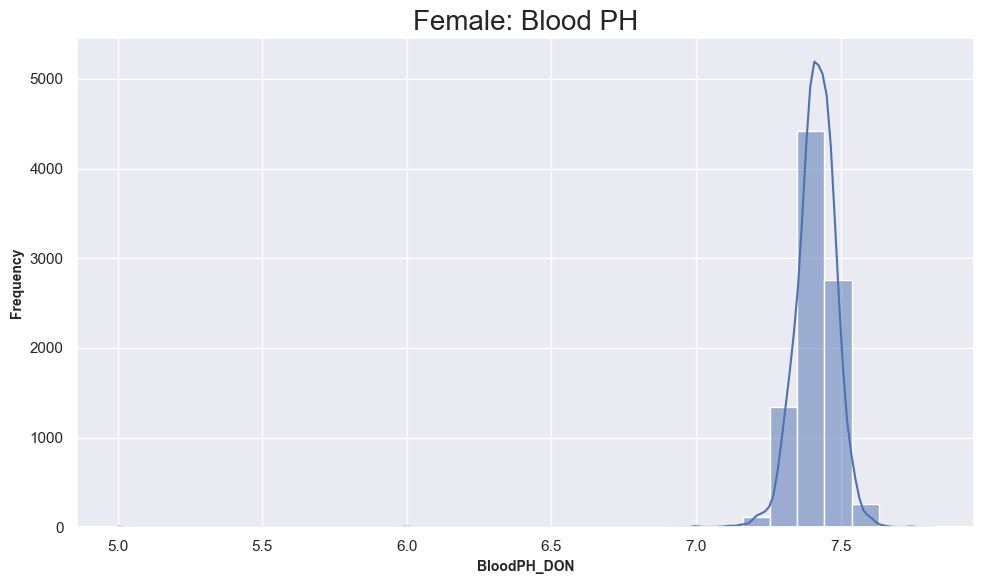

In [68]:
plot_histogram(df_f, features[0], txt='Female: Blood PH', bins=30)

In [69]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): BloodPH_DON ---
Group Sizes:    (Unknown=20, Known=8,913)
Mean survival:  (Unknown=1,031.4d, Known=1,440.8d)
Difference:     -409.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0613
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.3544 (Small)
95% CI:        [-0.7932, 0.0844]
Result: Likely Random Missingness (Effect size not significant)



In [70]:
u.continuous_value_predicts_survival(df_f,features[0], txt='Female')

--- Value Predicts Survival (Female): BloodPH_DON ---
Pearson r=-0.030, p=0.004394 & Approx. Variance Explained=0.091%
Spearman r=-0.031, p=0.003234 & Approx. Variance Explained=0.097%



In a small sample of females, the direction and magnitude of the effect were consistent with those observed in males.

### The "Shadow Variable" (Indicator) + Median Imputation

In [71]:
# Create the binary flag
df_m['BloodPH_IsMissing'] = df_m['BloodPH_DON'].isna().astype(int)
df_f['BloodPH_IsMissing'] = df_f['BloodPH_DON'].isna().astype(int)

# Fill the original NaN with the median
df_m['BloodPH_DON'] = df_m['BloodPH_DON'].fillna(df_m['BloodPH_DON'].median())
df_f['BloodPH_DON'] = df_f['BloodPH_DON'].fillna(df_f['BloodPH_DON'].median())

# sanity check
df_m.BloodPH_IsMissing.sum(), df_f.BloodPH_IsMissing.sum()

(np.int64(57), np.int64(20))

## Level_SGOT
* In clinical practice, males generally have higher absolute levels of both AST (SGOT) and ALT (SGPT) compared to females. However, because ALT levels are significantly lower in women, females typically have a higher AST/ALT ratio.
* ALT Specificity: ALT is more heavily influenced by gender than AST. In healthy adults, median ALT levels can be 20% higher in men than in women.
* The AST/ALT Ratio: Even though women have lower absolute numbers, their ALT is disproportionately lower than their AST. This results in a higher "De Ritis" ratio in females (median $\approx$ 0.90) compared to males (median $\approx$ 0.81) when healthy.

### Male

In [72]:
# info
features = u.get_feature_info(df_m, 'Level_SGOT', cat=False)

                      count        mean         std  min   25%   50%   75%      max
Level_SGOT_ALT_DON  21322.0  116.051557  438.771940  0.3  24.0  41.0  82.0  44117.0
Level_SGOT_AST_DON  21322.0  106.393711  316.109883  0.3  27.0  46.0  90.0  10254.0

:::: NaN Count:
Level_SGOT_ALT_DON    43
Level_SGOT_AST_DON    43 



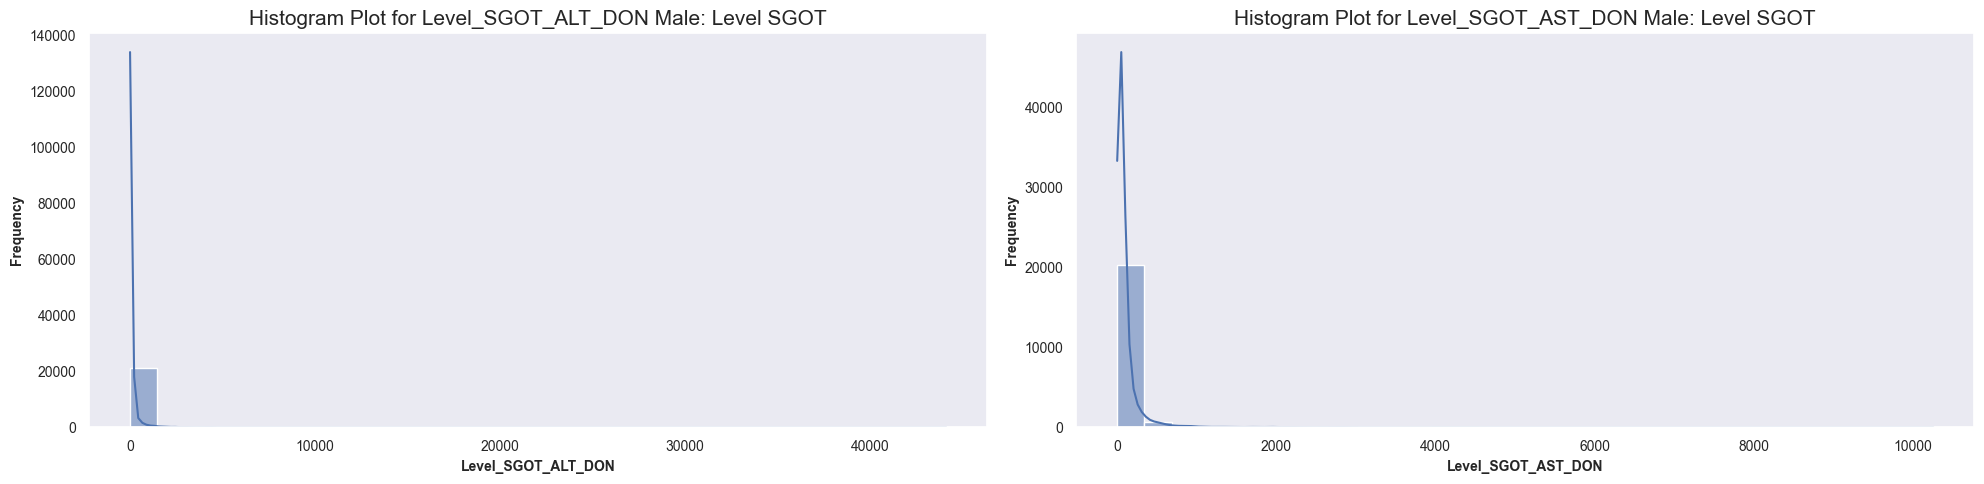

In [73]:
plot.plot_histogram(df_m, features,  txt='Male: Level SGOT')

In [74]:
for feature in features:
    u.check_informative_missingness(df_m, feature, txt='Male')

--- Missingness (Male): Level_SGOT_ALT_DON ---
Group Sizes:    (Unknown=43, Known=21,322)
Mean survival:  (Unknown=966.5d, Known=1,431.4d)
Difference:     -464.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0162
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.4022 (Small)
95% CI:        [-0.7014, -0.1030]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)

--- Missingness (Male): Level_SGOT_AST_DON ---
Group Sizes:    (Unknown=43, Known=21,322)
Mean survival:  (Unknown=966.5d, Known=1,431.4d)
Difference:     -464.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0162
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.4022 (Small)
95% CI:        [-0.7014, -0.1030]
Result: INFORMATIVE MISSINGNESS (statistically signif

#### Female

In [75]:
# info
features = u.get_feature_info(df_f, 'Level_SGOT', cat=False)

                     count        mean         std  min   25%   50%   75%     max
Level_SGOT_ALT_DON  8918.0  105.768569  280.479022  0.1  22.0  39.0  80.0  5900.0
Level_SGOT_AST_DON  8918.0   90.752074  247.773429  3.0  23.0  39.0  80.0  7802.0

:::: NaN Count:
Level_SGOT_ALT_DON    15
Level_SGOT_AST_DON    15 



In [76]:
for feature in features:
    u.check_informative_missingness(df_f, feature, txt='Female')

--- Missingness (Female): Level_SGOT_ALT_DON ---
Group Sizes:    (Unknown=15, Known=8,918)
Mean survival:  (Unknown=1,087.1d, Known=1,440.4d)
Difference:     -353.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2041
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.3059 (Small)
95% CI:        [-0.8124, 0.2006]
Result: Likely Random Missingness (Effect size not significant)

--- Missingness (Female): Level_SGOT_AST_DON ---
Group Sizes:    (Unknown=15, Known=8,918)
Mean survival:  (Unknown=1,087.1d, Known=1,440.4d)
Difference:     -353.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.2041
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.3059 (Small)
95% CI:        [-0.8124, 0.2006]
Result: Likely Random Missingness (Effect size not significant)



In a small sample of females, the direction and magnitude of the effect were consistent with those observed in males.

#### New Feature

In [77]:
# New Feature: AST/ALT
df_m['AST_ALT_Ratio'] =  df_m.Level_SGOT_AST_DON / df_m.Level_SGOT_ALT_DON
df_f['AST_ALT_Ratio'] =  df_f.Level_SGOT_AST_DON / df_f.Level_SGOT_ALT_DON

#### Log Transform

In [78]:
# Log Transform
df_m['Level_SGOT_ALT_Log'] = np.log1p(df_m.Level_SGOT_ALT_DON)
df_m['Level_SGOT_AST_Log'] = np.log1p(df_m.Level_SGOT_AST_DON)
df_m['AST_ALT_Ratio_Log'] = np.log1p(df_m.AST_ALT_Ratio)
# female
df_f['Level_SGOT_ALT_Log'] = np.log1p(df_f.Level_SGOT_ALT_DON)
df_f['Level_SGOT_AST_Log'] = np.log1p(df_f.Level_SGOT_AST_DON)
df_f['AST_ALT_Ratio_Log'] = np.log1p(df_f.AST_ALT_Ratio)

# remove
remove_cols = ['Level_SGOT_ALT_DON','Level_SGOT_AST_DON','AST_ALT_Ratio']
df_m = df_m.drop(columns=remove_cols)
df_f = df_f.drop(columns=remove_cols)

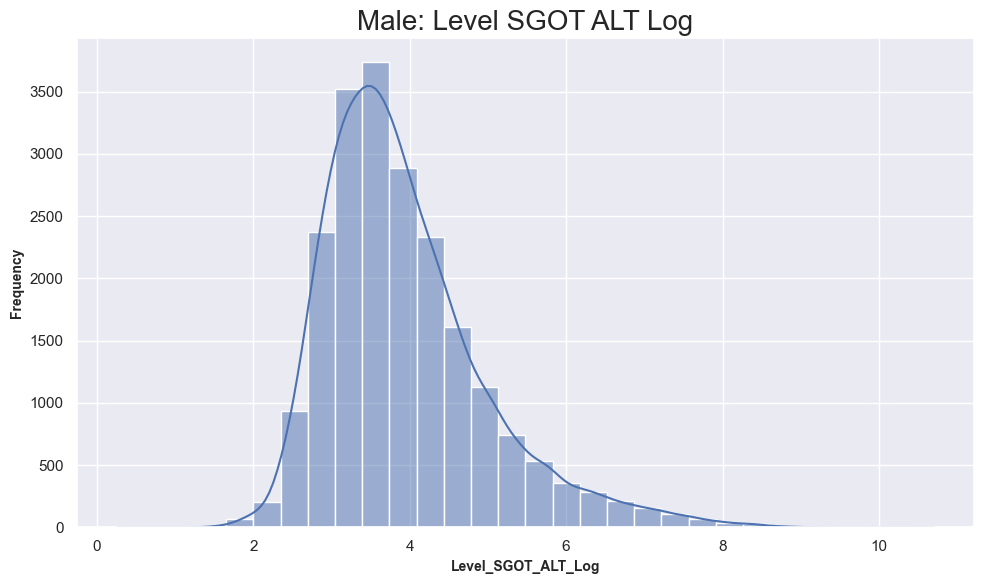

In [79]:
plot_histogram(df_m, 'Level_SGOT_ALT_Log', txt='Male: Level SGOT ALT Log', bins=30)

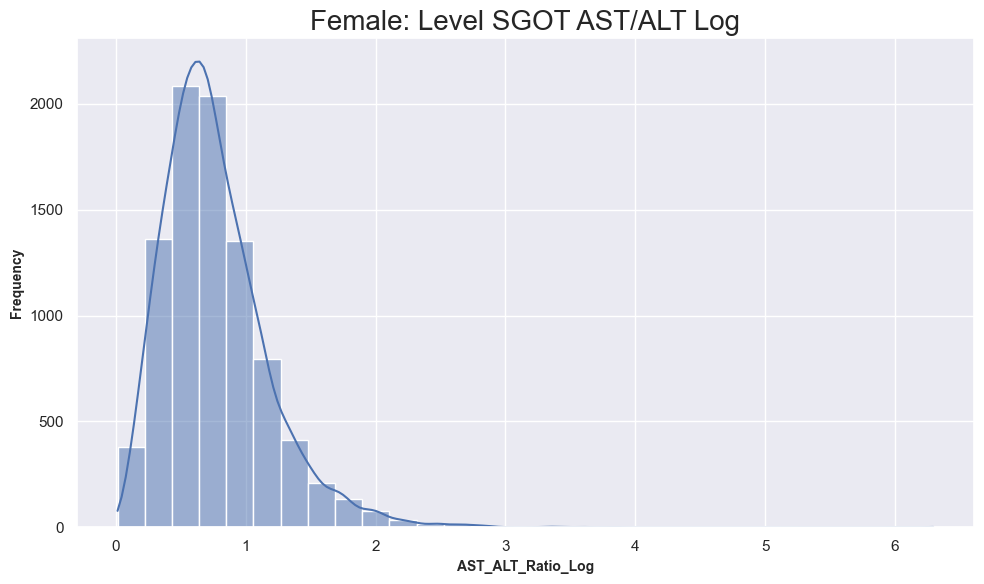

In [80]:
plot_histogram(df_f, 'AST_ALT_Ratio_Log', txt='Female: Level SGOT AST/ALT Log', bins=30)

### The "Shadow Variable" (Indicator) + Median Imputation

In [81]:
# impute: median and use new feature for NANS
df_m['Level_SGOT_ALT_Log_IsMissing'] = df_m.Level_SGOT_ALT_Log.isna().astype(int)
df_m['Level_SGOT_AST_Log_IsMissing'] = df_m.Level_SGOT_AST_Log.isna().astype(int)
df_m['AST_ALT_Ratio_Log_IsMissing'] = df_m.AST_ALT_Ratio_Log.isna().astype(int)
# female
df_f['Level_SGOT_ALT_Log_IsMissing'] = df_f.Level_SGOT_ALT_Log.isna().astype(int)
df_f['Level_SGOT_AST_Log_IsMissing'] = df_f.Level_SGOT_AST_Log.isna().astype(int)
df_f['AST_ALT_Ratio_Log_IsMissing'] = df_f.AST_ALT_Ratio_Log.isna().astype(int)
# sanity check
(df_m['Level_SGOT_ALT_Log_IsMissing'].sum(), df_m['Level_SGOT_AST_Log_IsMissing'].sum(), df_m['AST_ALT_Ratio_Log_IsMissing'].sum(), 
 df_f['Level_SGOT_ALT_Log_IsMissing'].sum(), df_f['Level_SGOT_AST_Log_IsMissing'].sum(), df_f['AST_ALT_Ratio_Log_IsMissing'].sum()
)

(np.int64(43),
 np.int64(43),
 np.int64(43),
 np.int64(15),
 np.int64(15),
 np.int64(15))

In [82]:
# impute
df_m['Level_SGOT_ALT_Log'] = df_m.Level_SGOT_ALT_Log.fillna(df_m.Level_SGOT_ALT_Log.median())
df_m['Level_SGOT_AST_Log'] = df_m.Level_SGOT_AST_Log.fillna(df_m.Level_SGOT_AST_Log.median())
df_m['AST_ALT_Ratio_Log'] = df_m.AST_ALT_Ratio_Log.fillna(df_m.AST_ALT_Ratio_Log.median())
# female
df_f['Level_SGOT_ALT_Log'] = df_f.Level_SGOT_ALT_Log.fillna(df_f.Level_SGOT_ALT_Log.median())
df_f['Level_SGOT_AST_Log'] = df_f.Level_SGOT_AST_Log.fillna(df_f.Level_SGOT_AST_Log.median())
df_f['AST_ALT_Ratio_Log'] = df_f.AST_ALT_Ratio_Log.fillna(df_f.AST_ALT_Ratio_Log.median())

## Terminal Total Bilirubin
* Bilirubin levels can be an important factor in heart transplantation, particularly in the context of post-operative outcomes. Elevated bilirubin levels, or hyperbilirubinemia, can indicate liver dysfunction, which is a common complication following cardiac surgery, including heart transplantation.
    * Prognostic Marker: Hyperbilirubinemia is often used as a prognostic marker for adverse outcomes after cardiac surgery. Elevated bilirubin levels are associated with increased in-hospital mortality, prolonged ICU stays, and other complications.
    * Incidence and Risk Factors: The incidence of hyperbilirubinemia after cardiac surgery varies widely, with reports ranging from 8.6% to 40%. Risk factors include the type of surgery, duration of cardiopulmonary bypass, and pre-existing liver conditions.
    * Management: Managing elevated bilirubin levels involves addressing the underlying causes, such as improving liver perfusion and reducing hemolysis. Treatments like bilirubin adsorption and plasma exchange have been studied for their efficacy in reducing bilirubin levels and improving outcomes.
    * Impact on Transplant Outcomes: High bilirubin levels can complicate the post-operative course and affect the overall success of the heart transplant. Monitoring and managing bilirubin levels is crucial for improving patient outcomes.

**Note:** Men generally have higher serum bilirubin levels than women, with average levels around in men compared to in women, a trend that holds across various age groups. This difference is likely driven by higher red blood cell counts in men and potential effects of sex hormones, such as progesterone and estradiol (key female sex hormones produced by the ovaries that regulate the menstrual cycle, pregnancy, and menopause).

#### Male

In [83]:
# info
features = u.get_feature_info(df_m, 'TerminalTotalBilirubin_DON', cat=False) 

                              count     mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON  21322.0  1.09689  1.457339  0.0  0.5  0.8  1.2  59.0

:::: NaN Count:
TerminalTotalBilirubin_DON    43 



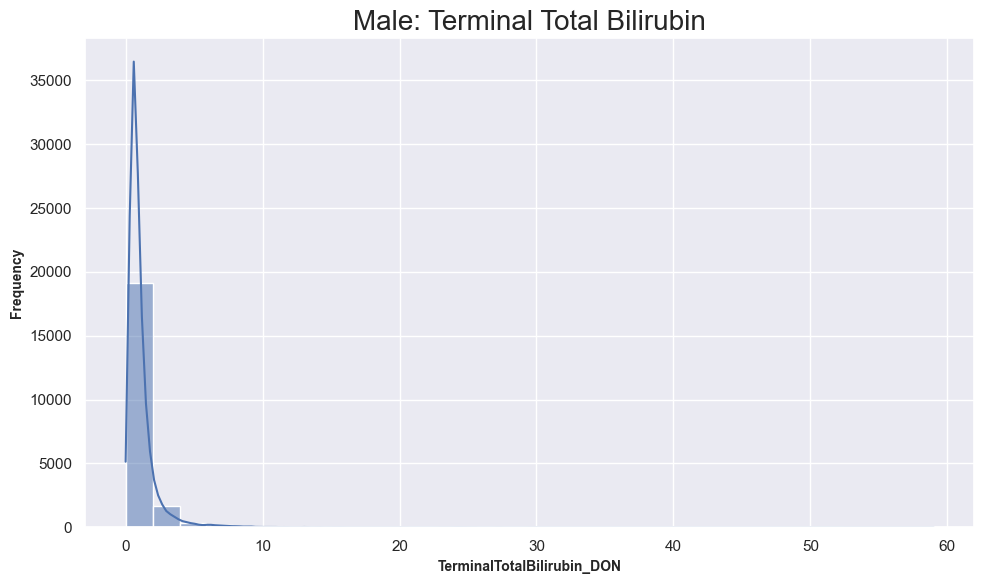

In [84]:
plot_histogram(df_m, features[0], txt='Male: Terminal Total Bilirubin', bins=30)

In [85]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): TerminalTotalBilirubin_DON ---
Group Sizes:    (Unknown=43, Known=21,322)
Mean survival:  (Unknown=966.5d, Known=1,431.4d)
Difference:     -464.9 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0162
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.4022 (Small)
95% CI:        [-0.7014, -0.1030]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Female

In [86]:
# info
features = u.get_feature_info(df_f, 'TerminalTotalBilirubin_DON', cat=False) 

                             count      mean       std  min  25%  50%  75%   max
TerminalTotalBilirubin_DON  8919.0  0.935151  1.488818  0.0  0.4  0.6  1.0  33.9

:::: NaN Count:
TerminalTotalBilirubin_DON    14 



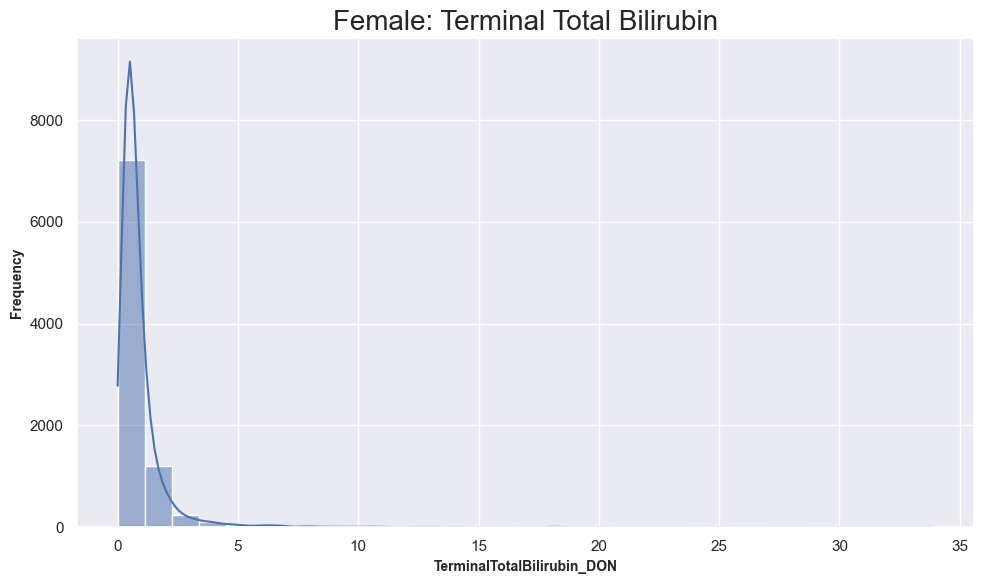

In [87]:
plot_histogram(df_f,  features[0], txt='Female: Terminal Total Bilirubin', bins=30)

In [88]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): TerminalTotalBilirubin_DON ---
Group Sizes:    (Unknown=14, Known=8,919)
Mean survival:  (Unknown=1,034.0d, Known=1,440.5d)
Difference:     -406.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1691
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.3519 (Small)
95% CI:        [-0.8762, 0.1724]
Result: Likely Random Missingness (Effect size not significant)



#### Log Transform

In [89]:
# Log Transform
df_m['TerminalTotalBilirubin_Log'] = np.log1p(df_m[features[0]])
# female
df_f['TerminalTotalBilirubin_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

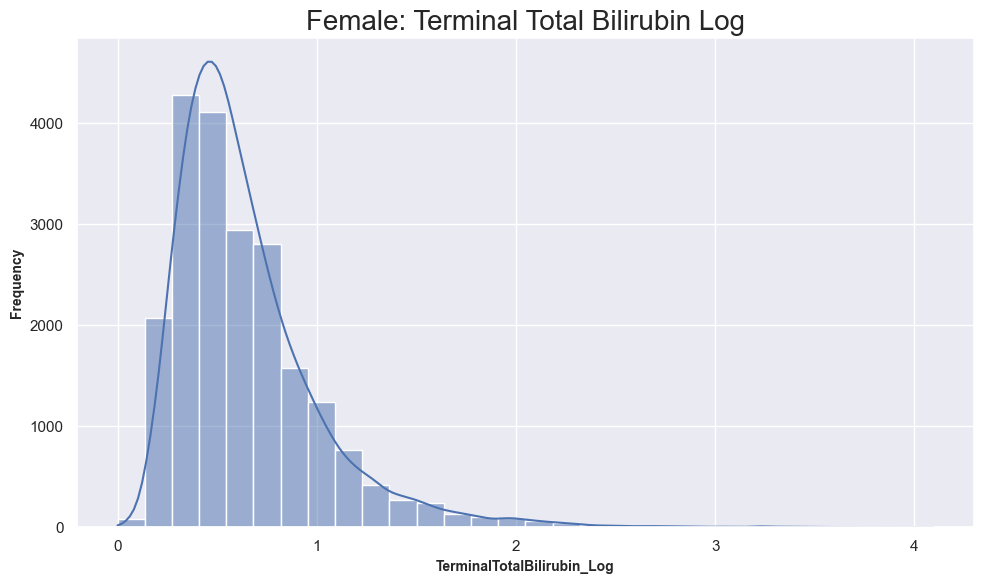

In [90]:
plot_histogram(df_m, 'TerminalTotalBilirubin_Log', txt='Female: Terminal Total Bilirubin Log', bins=30)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [91]:
# impute: median and use new feature for NANS
df_m['TerminalTotalBilirubin_Log_IsMissing'] = df_m.TerminalTotalBilirubin_Log.isna().astype(int)
# female
df_f['TerminalTotalBilirubin_Log_IsMissing'] = df_f.TerminalTotalBilirubin_Log.isna().astype(int)
# median
df_m['TerminalTotalBilirubin_Log'] = df_m.TerminalTotalBilirubin_Log.fillna(df_m.TerminalTotalBilirubin_Log.median())
# female
df_f['TerminalTotalBilirubin_Log'] = df_f.TerminalTotalBilirubin_Log.fillna(df_f.TerminalTotalBilirubin_Log.median())
# sanity check
df_m['TerminalTotalBilirubin_Log_IsMissing'].sum(), df_f['TerminalTotalBilirubin_Log_IsMissing'].sum()

(np.int64(43), np.int64(14))

## [Blood Urea Nitrogen Level](https://redcliffelabs.com/myhealth/lab-test/urea-normal-range-causes-procedure-and-treatment/)
*  Blood Urea Nitrogen (BUN) is a common blood test that measures the amount of urea nitrogen in the blood, which is a waste product formed from the breakdown of proteins.
    - Source reports a range of 8 to 24 mg/dL for adult men and 6 to 21 mg/dL for adult women. 

#### Male

In [92]:
# info
features = u.get_feature_info(df_m, 'BloodUreaNitrogenLevel', cat=False) 

                              count       mean        std   min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  21326.0  24.610073  20.243246  0.72  13.0  19.0  29.0  250.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    39 



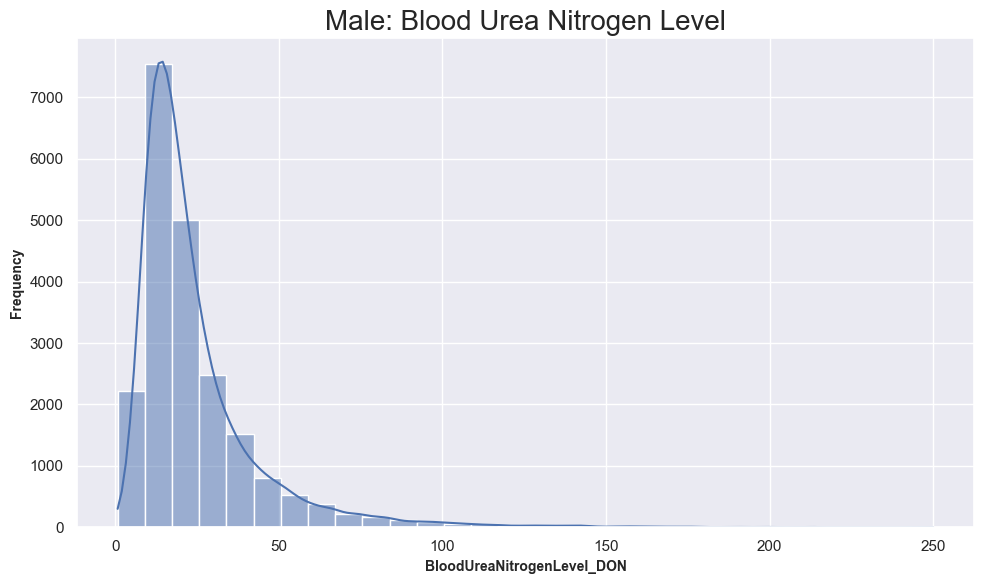

In [93]:
plot_histogram(df_m, features[0], txt='Male: Blood Urea Nitrogen Level', bins=30)

In [94]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): BloodUreaNitrogenLevel_DON ---
Group Sizes:    (Unknown=39, Known=21,326)
Mean survival:  (Unknown=819.2d, Known=1,431.6d)
Difference:     -612.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0012
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.5298 (Medium)
95% CI:        [-0.8439, -0.2156]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



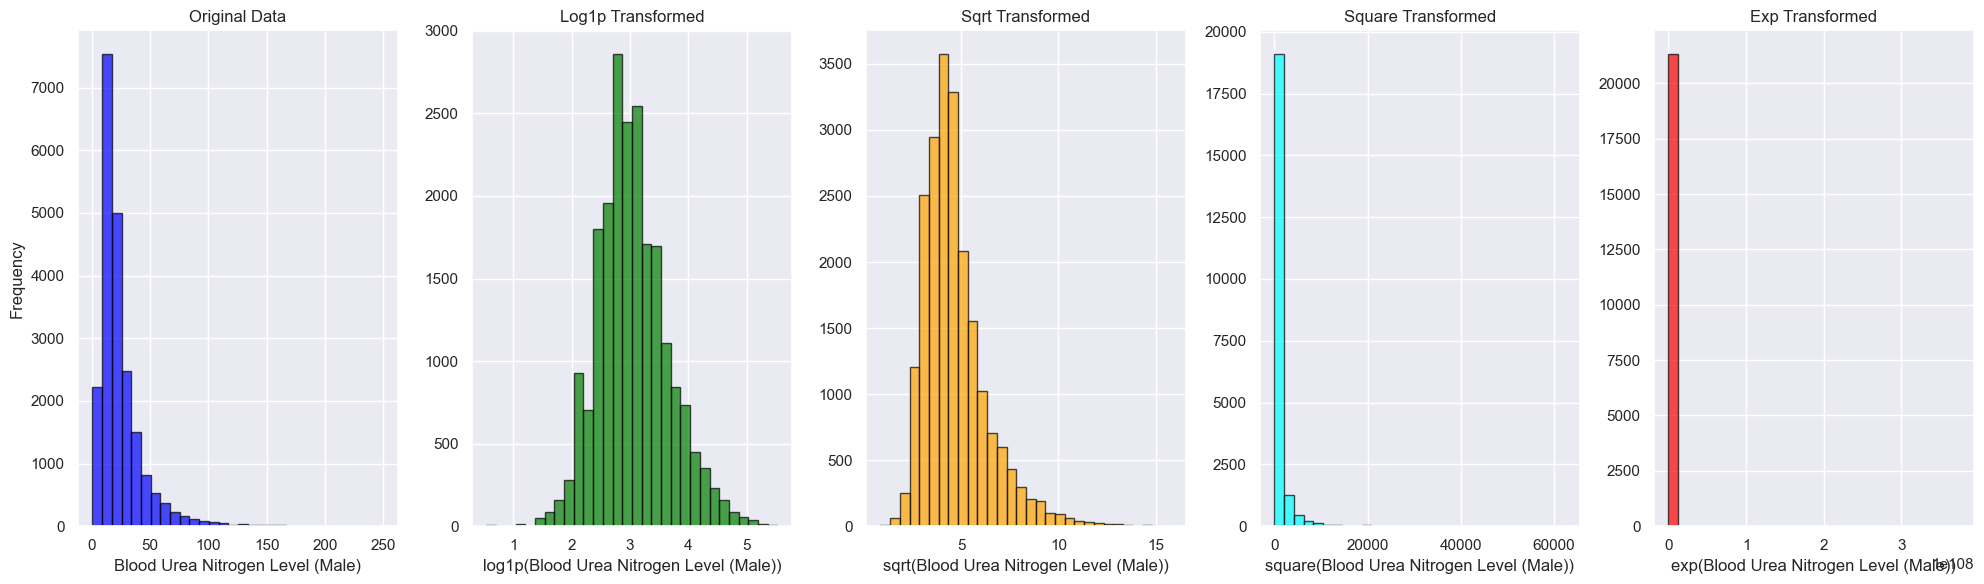

In [95]:
plot.plot_transform_distribution(df_m[features[0]], txt='Blood Urea Nitrogen Level (Male)')

#### Female

In [96]:
# info
features = u.get_feature_info(df_f, 'BloodUreaNitrogenLevel', cat=False) 

                             count       mean        std  min   25%   50%   75%    max
BloodUreaNitrogenLevel_DON  8918.0  20.749749  17.645449  0.5  10.0  16.0  25.0  230.0

:::: NaN Count:
BloodUreaNitrogenLevel_DON    15 



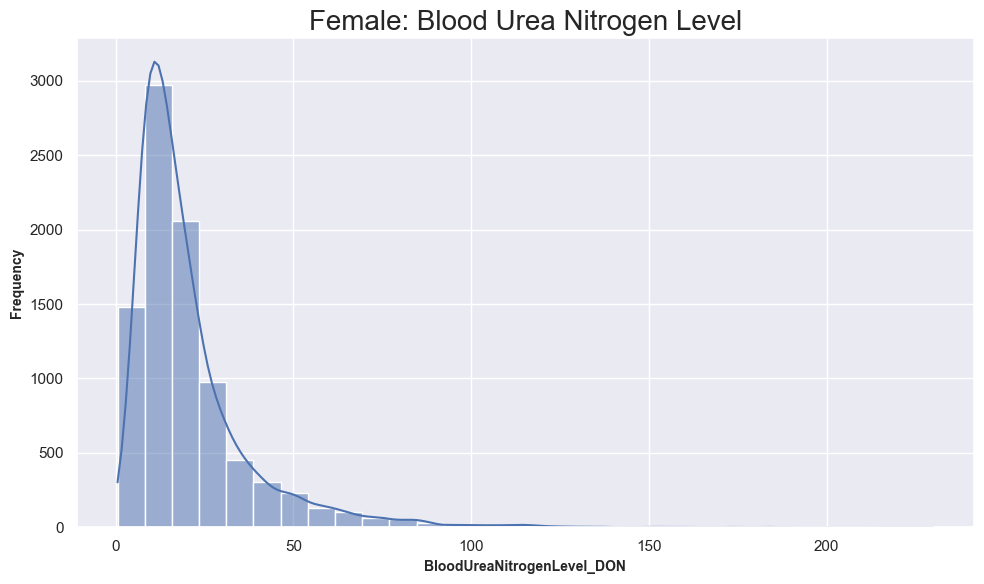

In [97]:
plot_histogram(df_f, features[0], txt='Female: Blood Urea Nitrogen Level', bins=30)

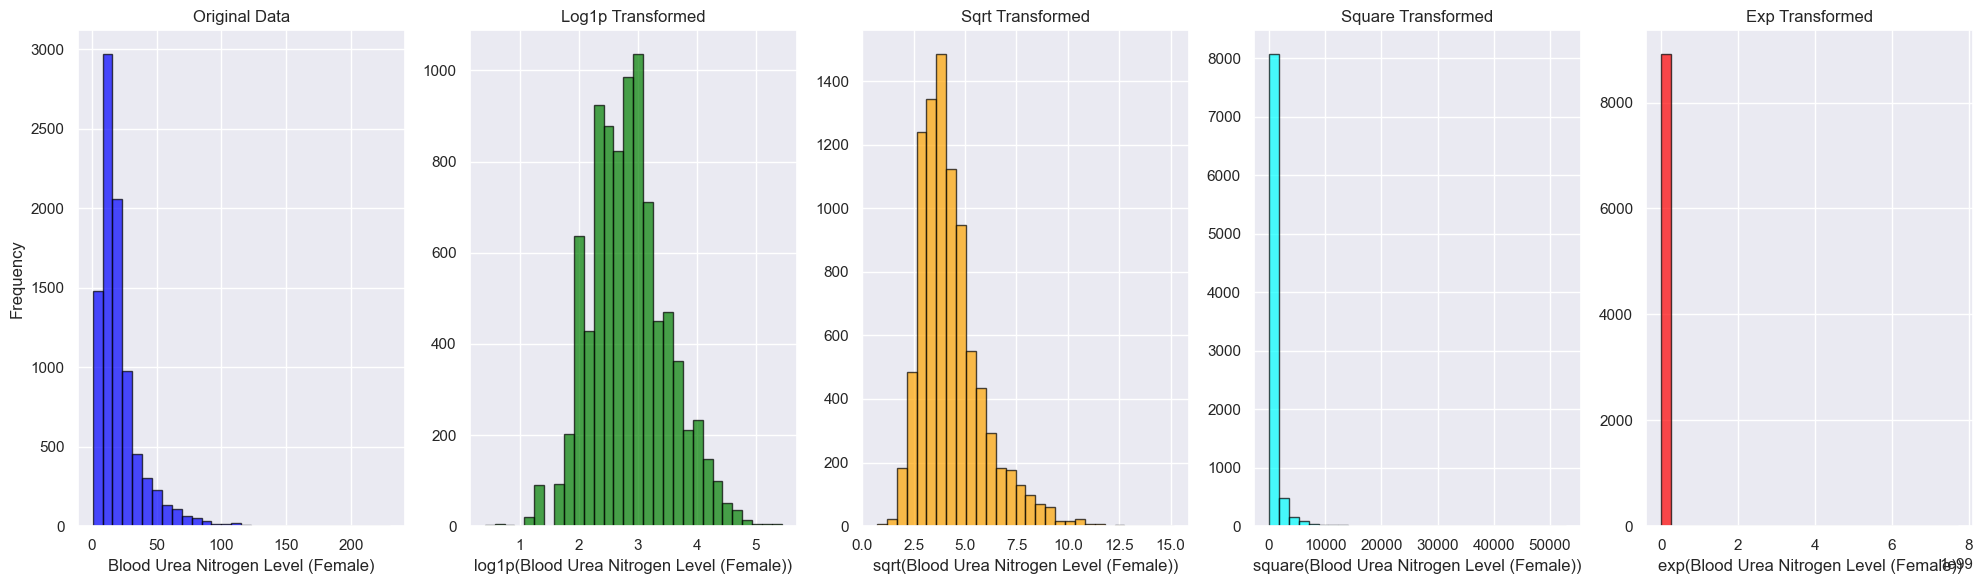

In [98]:
plot.plot_transform_distribution(df_f[features[0]], txt='Blood Urea Nitrogen Level (Female)')

#### Log Transform

In [99]:
# Log Transform
df_m['BloodUreaNitrogenLevel_Log'] = np.log1p(df_m[features[0]])
# female
df_f['BloodUreaNitrogenLevel_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(features[0], axis=1)
df_f = df_f.drop(features[0], axis=1)

#### The "Shadow Variable" (Indicator) + Median Imputationm

In [100]:
# impute: median and use new feature for NANS
df_m['BloodUreaNitrogenLevel_Log_IsMissing'] = df_m.BloodUreaNitrogenLevel_Log.isna().astype(int)
# female
df_f['BloodUreaNitrogenLevel_Log_IsMissing'] = df_f.BloodUreaNitrogenLevel_Log.isna().astype(int)
# median
df_m['BloodUreaNitrogenLevel_Log'] = df_m.BloodUreaNitrogenLevel_Log.fillna(df_m.BloodUreaNitrogenLevel_Log.median())
# female
df_f['BloodUreaNitrogenLevel_Log'] = df_f.BloodUreaNitrogenLevel_Log.fillna(df_f.BloodUreaNitrogenLevel_Log.median())
# sanity check
df_m['BloodUreaNitrogenLevel_Log_IsMissing'].sum(), df_f['BloodUreaNitrogenLevel_Log_IsMissing'].sum()

(np.int64(39), np.int64(15))

## [Creatinine](https://johnshopkinshealthcare.staywellsolutionsonline.com/BreatheEasy/167,creatinine_serum)
* Creatinine is a waste product that forms when creatine, a substance found in your muscles, breaks down. It's usually filtered out of the blood by the kidneys and excreted in urine. Measuring creatinine levels in the blood can help assess kidney function.
    * Normal
        * 0.7 to 1.3 mg/dL for adult males
        * 0.5 to 1.1 mg/dL for adult females
* High creatinine indicates elevated levels of a waste product in the blood, primarily signaling that the kidneys are not filtering efficiently, commonly termed renal dysfunction, impaired kidney function, or kidney damage.

#### Male

In [101]:
# info
features = u.get_feature_info(df_m, 'Creatinine', cat=False) 

                  count      mean       std   min  25%   50%  75%   max
Creatinine_DON  21326.0  1.572822  1.606931  0.05  0.8  1.07  1.5  23.0

:::: NaN Count:
Creatinine_DON    39 



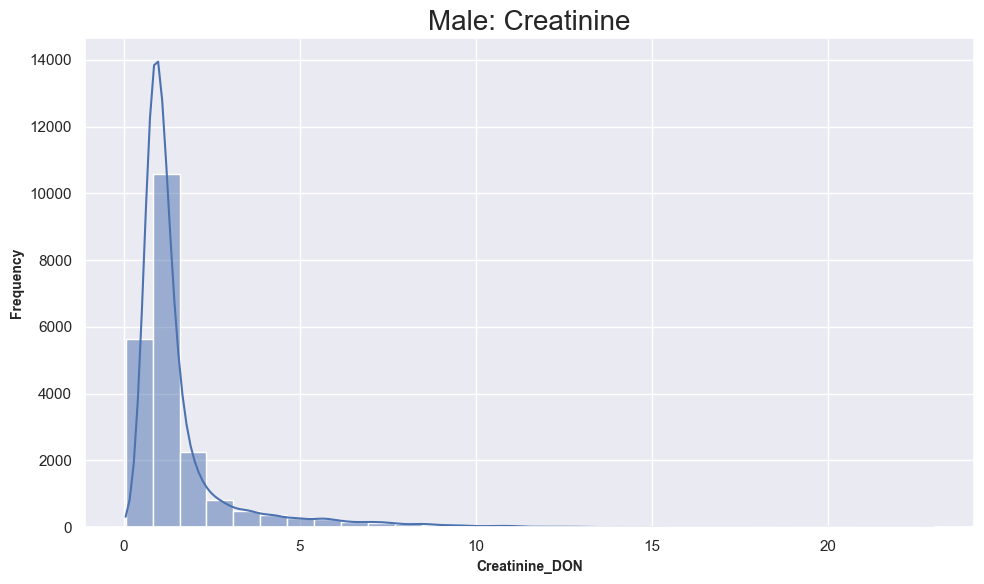

In [102]:
plot_histogram(df_m, features[0], txt='Male: Creatinine', bins=30)

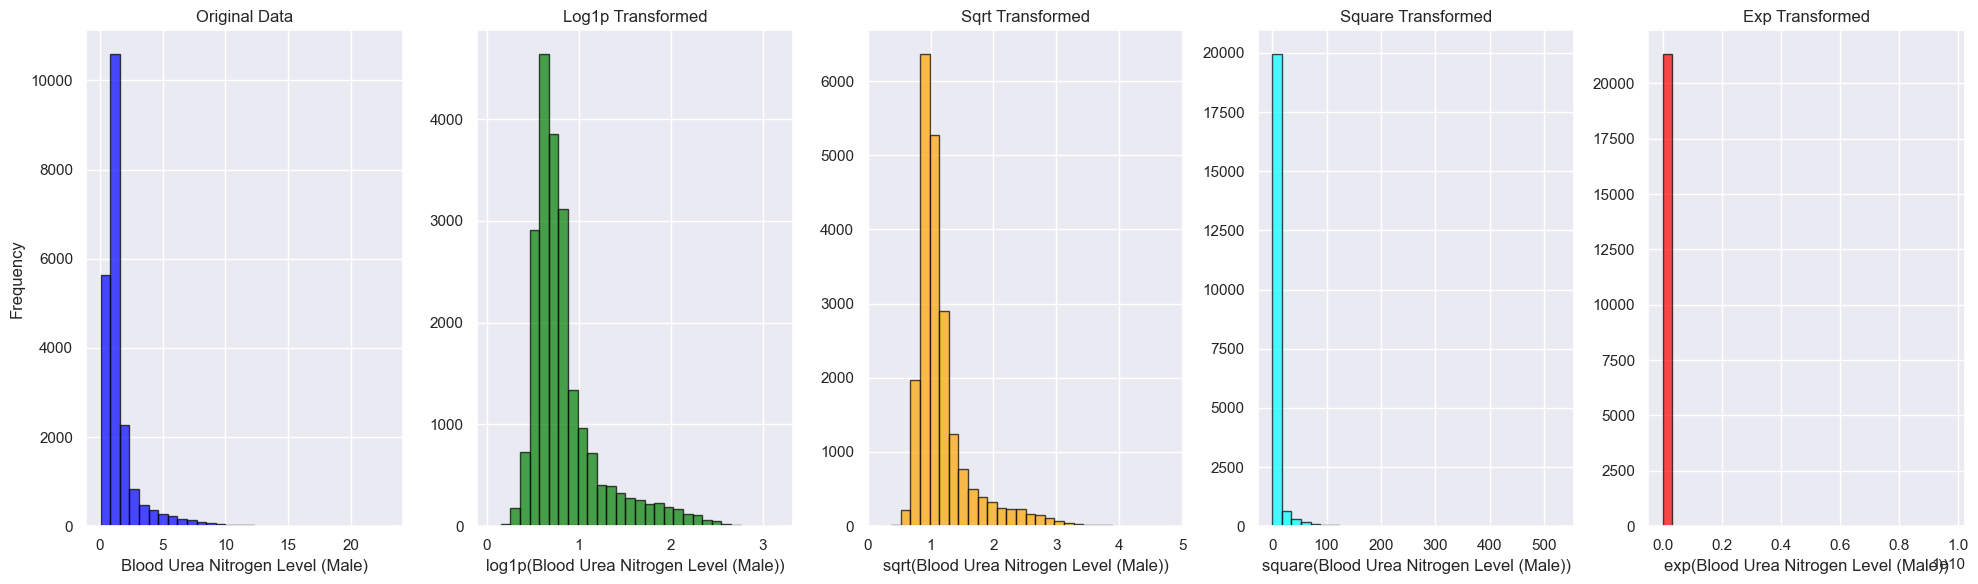

In [103]:
plot.plot_transform_distribution(df_m[features[0]], txt='Blood Urea Nitrogen Level (Male)')

In [104]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): Creatinine_DON ---
Group Sizes:    (Unknown=39, Known=21,326)
Mean survival:  (Unknown=819.2d, Known=1,431.6d)
Difference:     -612.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0012
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.5298 (Medium)
95% CI:        [-0.8439, -0.2156]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Female

In [105]:
# info
features = u.get_feature_info(df_f, 'Creatinine', cat=False) 

                 count      mean       std   min   25%   50%   75%   max
Creatinine_DON  8918.0  1.281004  1.340134  0.04  0.61  0.81  1.27  18.0

:::: NaN Count:
Creatinine_DON    15 



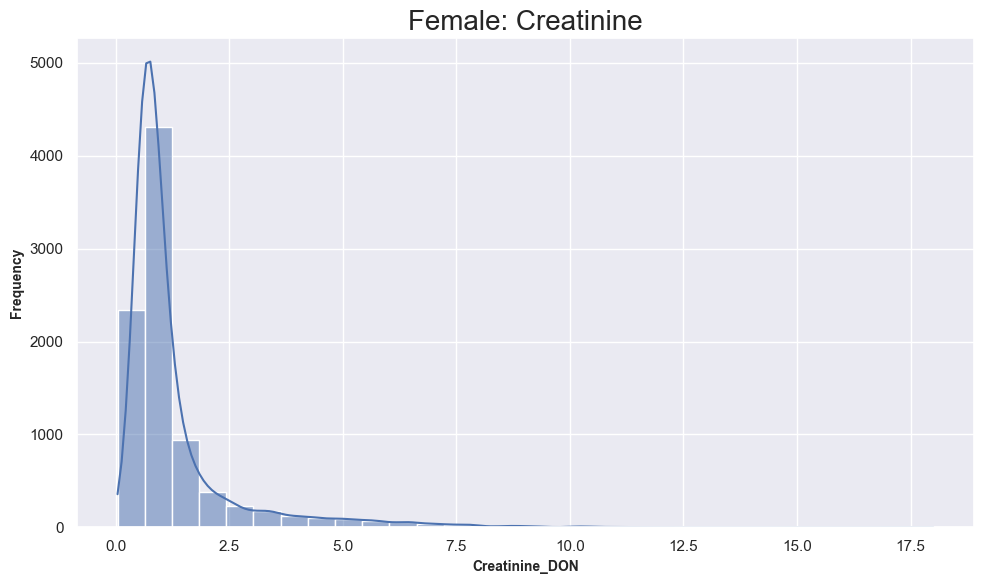

In [106]:
plot_histogram(df_f, features[0], txt='Female: Creatinine', bins=30)

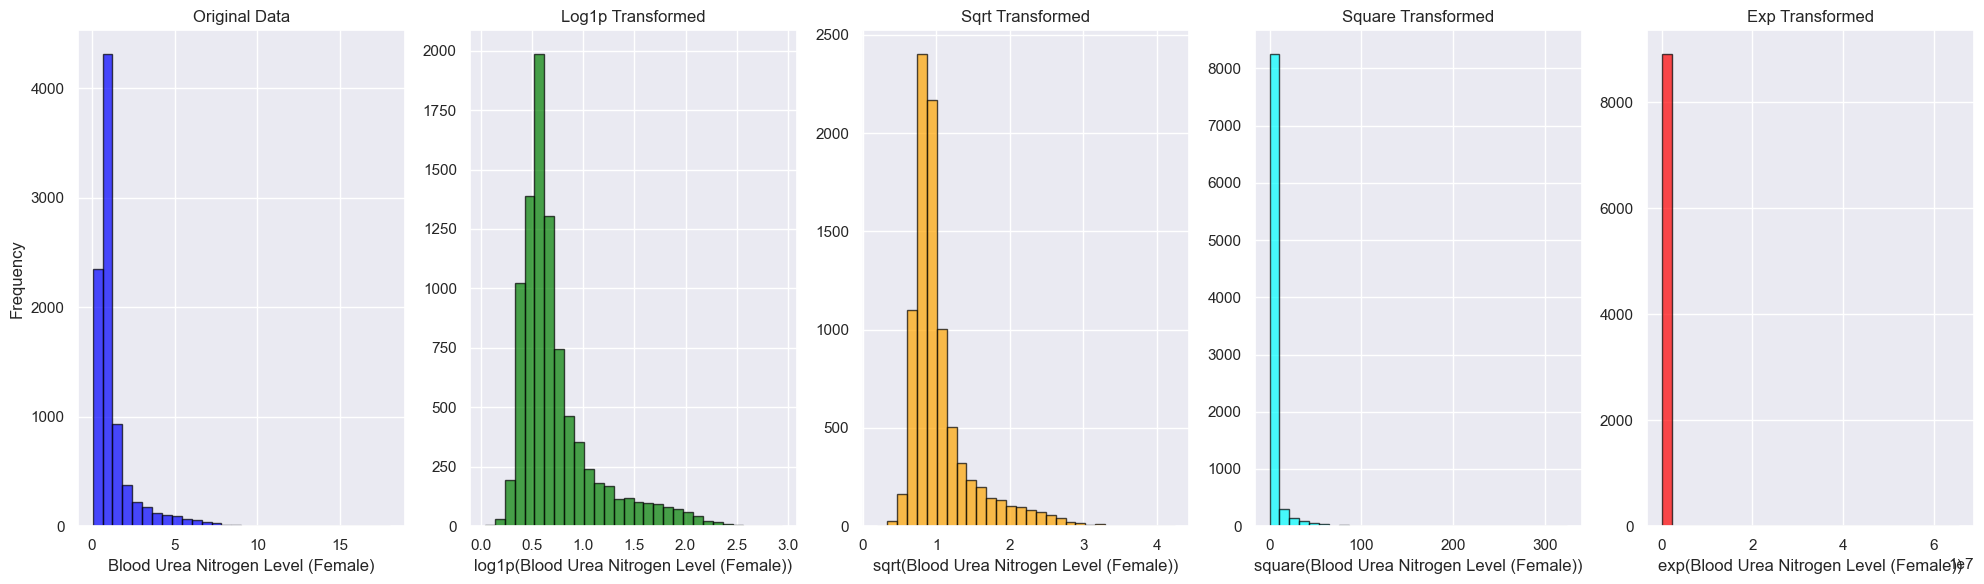

In [107]:
plot.plot_transform_distribution(df_f[features[0]], txt='Blood Urea Nitrogen Level (Female)')

#### Log Transform

In [108]:
# Log Transform
df_m['Creatinine_Log'] = np.log1p(df_m[features[0]])
# female
df_f['Creatinine_Log'] = np.log1p(df_f[features[0]])
# remove
df_m = df_m.drop(columns=features)
df_f = df_f.drop(columns=features)

#### The "Shadow Variable" (Indicator) + Median Imputation

In [109]:
# impute: median and use new feature for NANS
df_m['Creatinine_Log_IsMissing'] = df_m.Creatinine_Log.isna().astype(int)
# female
df_f['Creatinine_Log_IsMissing'] = df_f.Creatinine_Log.isna().astype(int)
# median
df_m['Creatinine_Log'] = df_m.Creatinine_Log.fillna(df_m.Creatinine_Log.median())
# female
df_f['Creatinine_Log'] = df_f.Creatinine_Log.fillna(df_f.Creatinine_Log.median())
# sanity check
df_m['Creatinine_Log_IsMissing'].sum(), df_f['Creatinine_Log_IsMissing'].sum()

(np.int64(39), np.int64(15))

## [Hematocrit](https://www.mountsinai.org/health-library/tests/hematocrit)
* Hematocrit is a blood test that measures how much of a person's blood is made up of red blood cells as opposed to plasma.
    - Normal results vary, but in general they are:
        - Male: 40.7% to 50.3%
        - Female: 36.1% to 44.3% 

#### Male

In [110]:
# info
features = u.get_feature_info(df_m, 'Hematocrit', cat=False) 

                  count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  21326.0  28.822668  5.198125  2.5  25.1  28.2  32.0  75.0

:::: NaN Count:
Hematocrit_DON    39 



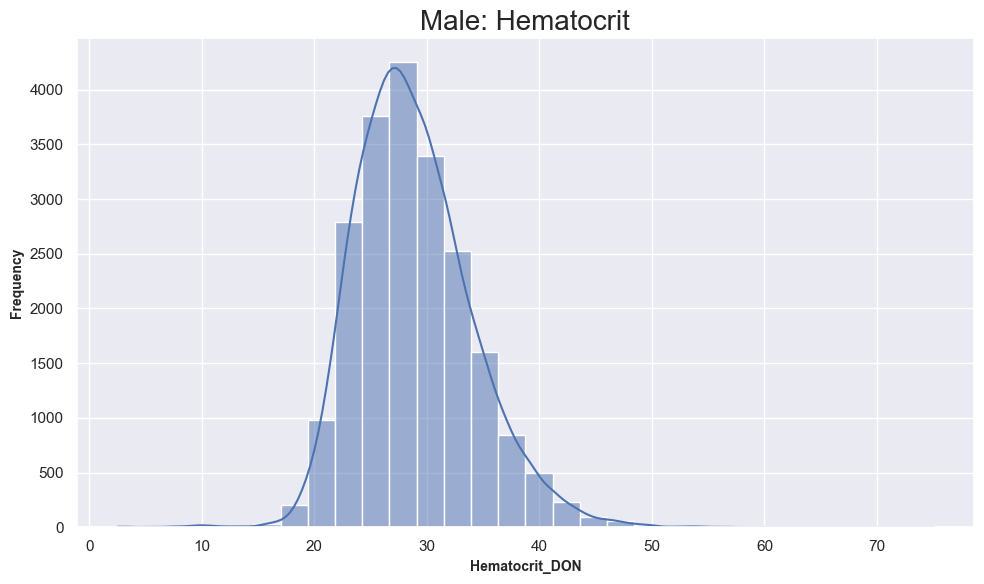

In [111]:
plot_histogram(df_m, features[0], txt='Male: Hematocrit', bins=30)

In [112]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): Hematocrit_DON ---
Group Sizes:    (Unknown=39, Known=21,326)
Mean survival:  (Unknown=819.2d, Known=1,431.6d)
Difference:     -612.4 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0012
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     -0.5298 (Medium)
95% CI:        [-0.8439, -0.2156]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Female

In [113]:
# info
features = u.get_feature_info(df_f, 'Hematocrit', cat=False) 

                 count       mean       std  min   25%   50%   75%   max
Hematocrit_DON  8919.0  27.897493  4.437392  1.0  25.0  27.6  30.4  56.4

:::: NaN Count:
Hematocrit_DON    14 



In [114]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): Hematocrit_DON ---
Group Sizes:    (Unknown=14, Known=8,919)
Mean survival:  (Unknown=1,034.0d, Known=1,440.5d)
Difference:     -406.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.1691
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     -0.3519 (Small)
95% CI:        [-0.8762, 0.1724]
Result: Likely Random Missingness (Effect size not significant)



**Note:** The sample size for the missing-data subgroup (n < 30) limits the reliability of inferential statistics, as both Welch’s t-test and Cohen’s d are subject to low statistical power and unstable sampling variability in small samples. Consequently, formal significance testing and effect size estimates from this comparison should be interpreted with caution. Despite these limitations, the observed survival difference of more than 500 days for males and more than 300 days for females suggests that missingness in Hematocrit_DON may convey clinically relevant information, consistent with potentially informative missingness (i.e., not MCAR). However, given the very low proportion of missing data (<<1%), we avoid complex imputation procedures that would introduce unnecessary modeling assumptions. Instead, we apply a median imputation strategy combined with a missingness indicator (shadow variable), allowing the model to retain the potential signal associated with missingness.

#### The "Shadow Variable" (Indicator) + Median Imputation

In [115]:
# impute: median and use new feature for NANS
df_m['Hematocrit_IsMissing'] = df_m.Hematocrit_DON.isna().astype(int)
# female
df_f['Hematocrit_IsMissing'] = df_f.Hematocrit_DON.isna().astype(int)
# median
df_m['Hematocrit_DON'] = df_m.Hematocrit_DON.fillna(df_m.Hematocrit_DON.median())
# female
df_f['Hematocrit_DON'] = df_f.Hematocrit_DON.fillna(df_f.Hematocrit_DON.median())
# sanity check
df_m['Hematocrit_IsMissing'].sum(), df_f['Hematocrit_IsMissing'].sum()

(np.int64(39), np.int64(14))

## [LV_Ejection Fraction Percent](https://my.clevelandclinic.org/health/articles/16950-ejection-fraction)
* Ejection fraction measures your heart’s ability to pump oxygen-rich blood out to your body. In a healthy heart, the fraction is a higher number. A low number means that your heart has difficulty keeping up with your body’s needs.
    * Male:
        * Normal: 52% to 72%
        * Mildly Abnormal: 41% to 51%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 
    * Female:
        * Normal: 54% to 74%
        * Mildly Abnormal: 41% to 53%
        * Moderately Abnormal: 30% to 40%
        * Severely Abnormal: Below 30% 

#### Male

In [116]:
# info
features = u.get_feature_info(df_m, 'LV_EjectionFractionPercent', cat=False) 

                                  count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  21340.0  61.454794  6.704695  10.0  55.0  60.0  65.0  99.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    25 



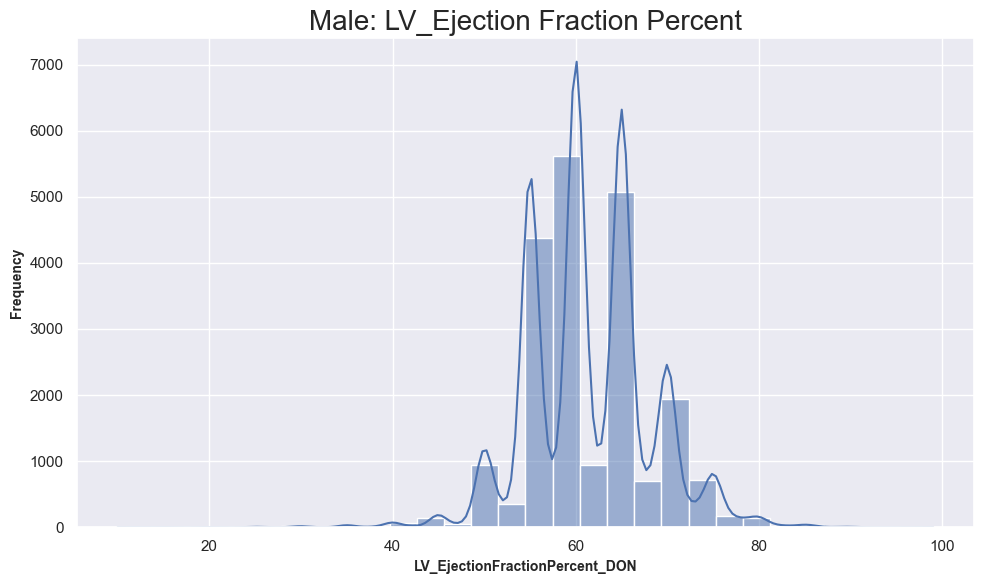

In [117]:
plot_histogram(df_m, features[0], txt='Male: LV_Ejection Fraction Percent', bins=30)

In [118]:
u.check_informative_missingness(df_m, features[0], txt='Male')

--- Missingness (Male): LV_EjectionFractionPercent_DON ---
Group Sizes:    (Unknown=25, Known=21,340)
Mean survival:  (Unknown=2,014.5d, Known=1,429.8d)
Difference:     584.7 days

--- Welch's t-test Analysis ---
ρ-Value: 0.0339
RESULT: Missingness is associated with survival (informative missingness).
Interpretation: Not MCAR. Likely MAR or MNAR.

--- Cohen's Analysis ---
Cohen's d:     0.5057 (Medium)
95% CI:        [0.1135, 0.8980]
Result: INFORMATIVE MISSINGNESS (statistically significant difference; small effect size)



#### Female

In [119]:
# info
features = u.get_feature_info(df_f, 'LV_EjectionFractionPercent', cat=False) 

                                 count       mean       std   min   25%   50%   75%   max
LV_EjectionFractionPercent_DON  8924.0  61.991936  6.605026  20.0  57.0  60.0  65.0  91.0

:::: NaN Count:
LV_EjectionFractionPercent_DON    9 



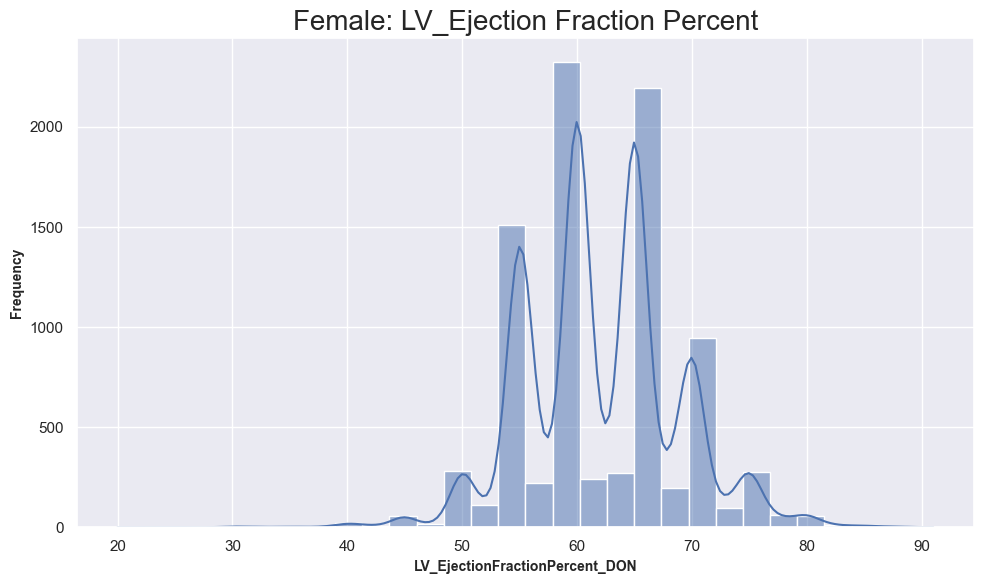

In [120]:
plot_histogram(df_f, features[0], txt='Female: LV_Ejection Fraction Percent', bins=30)

In [121]:
u.check_informative_missingness(df_f, features[0], txt='Female')

--- Missingness (Female): LV_EjectionFractionPercent_DON ---
Group Sizes:    (Unknown=9, Known=8,924)
Mean survival:  (Unknown=1,805.0d, Known=1,439.5d)
Difference:     365.5 days

--- Welch's t-test Analysis ---
ρ-Value: 0.3012
RESULT: No strong evidence that missingness affects survival.
Interpretation: Consistent with MCAR (but not definitive).

--- Cohen's Analysis ---
Cohen's d:     0.3164 (Small)
95% CI:        [-0.3372, 0.9701]
Result: Likely Random Missingness (Effect size not significant)



**Note:** The small size of the missing-data subgroup (n < 30) limits the reliability of inferential statistics, as both Welch’s t-test and Cohen’s d have low power and unstable sampling variability in this setting. Consequently, formal significance tests and effect size estimates from this comparison should be interpreted with caution. Despite these limitations, the observed survival difference of more than 400 days suggests that missingness in LV_EjectionFractionPercent_DON may convey clinically relevant information, consistent with potentially informative missingness (i.e., not MCAR). However, given the very low proportion of missing data (≪1%), we avoid complex imputation procedures that would introduce additional modeling assumptions. Instead, we apply median imputation combined with a missingness indicator (shadow variable), allowing the model to retain the potential signal associated with missingness even when the underlying distribution is multimodal.

#### The "Shadow Variable" (Indicator) + Median Imputation (small sample size)

In [122]:
# impute: median and use new feature for NANS
df_m['LV_EjectionFractionPercent_IsMissing'] = df_m[features[0]].isna().astype(int)
# female
df_f['LV_EjectionFractionPercent_IsMissing'] = df_f[features[0]].isna().astype(int)
# median
df_m[features[0]] = df_m[features[0]].fillna(df_m[features[0]].median())
# female
df_f[features[0]] = df_f[features[0]].fillna(df_f[features[0]].median())
# sanity check
df_m['LV_EjectionFractionPercent_IsMissing'].sum(), df_f['LV_EjectionFractionPercent_IsMissing'].sum()

(np.int64(25), np.int64(9))

### BMI

In [123]:
# info
features = u.get_feature_info(df_m, 'BMI_', cat=False) 

                    count       mean      std        min        25%        50%        75%        max
BMI_Donation_DON  21361.0  26.978186  5.43234  14.351881  23.148148  26.122449  29.839952  66.435986

:::: NaN Count:
BMI_Donation_DON    4 



In [124]:
# info
features = u.get_feature_info(df_f, 'BMI_', cat=False) 

                   count       mean       std        min        25%        50%        75%        max
BMI_Donation_DON  8928.0  28.958271  7.062557  13.121499  23.849167  27.665437  32.787711  74.360965

:::: NaN Count:
BMI_Donation_DON    5 



In [125]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

## Weight (Kg)

In [126]:
# info
features = u.get_feature_info(df_m, 'Weight', cat=False) 

                 count       mean        std   min   25%   50%   75%    max
Weight_kg_DON  21363.0  85.402729  18.741526  23.2  72.5  82.0  95.4  198.0

:::: NaN Count:
Weight_kg_DON    2 



In [127]:
# info
features = u.get_feature_info(df_f, 'Weight', cat=False) 

                count      mean        std   min   25%   50%   75%    max
Weight_kg_DON  8932.0  78.68586  20.243971  31.5  64.0  75.0  90.0  196.0

:::: NaN Count:
Weight_kg_DON    1 



In [128]:
# impute: median
df_m[features] = df_m[features].fillna(df_m[features].median())
# female
df_f[features] = df_f[features].fillna(df_f[features].median())

### OtherMedsText1_DON & OtherMedsText2_DON & OtherMedsText3_DON

#### Male

In [129]:
df_m["Meds_DON"].head()

0                                         ZOSYN, VANCOMYCIN, KCL, DOPAMINE, VASOPRESSIN
1                                                        ANCEF, FENTANYL, VERSED, LASIX
2                                     ZOSYN, VANCOMYCIN, AMPHOTERICIN, BETADINE, ZANTAC
5    MAG SULFATE, CEFAZOLIN, KPHOS, KCL, CA GLUCONATE, LEVOPHED, ROCURONIUM, VECURONIUM
6                                                                              LEVOPHED
Name: Meds_DON, dtype: object

In [130]:
# import library
from sklearn.feature_extraction.text import TfidfVectorizer

# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_male = tfidf.fit_transform(df_m["Meds_DON"])

# shape
X_meds_male.shape

(21365, 4217)

#### TruncatedSVD
* We used TruncatedSVD, also known as Latent Semantic Analysis (LSA), when applied to text to reduce the dimensionality of donor medication data, a classic high-cardinality feature where many drugs exist, and each donor receives only a small subset, producing a highly sparse matrix. Standard PCA performs poorly in this setting because it requires centering the data, which destroys sparsity and can create substantial memory overhead. In contrast, TruncatedSVD operates directly on the sparse representation without centering, making it computationally efficient and numerically stable for our exploratory analyses of medication patterns.

In [131]:
from sklearn.decomposition import TruncatedSVD

# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_male)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

(21365, 100)
0.6864451933697628


Optimal number of SVD components (Kneedle): 27


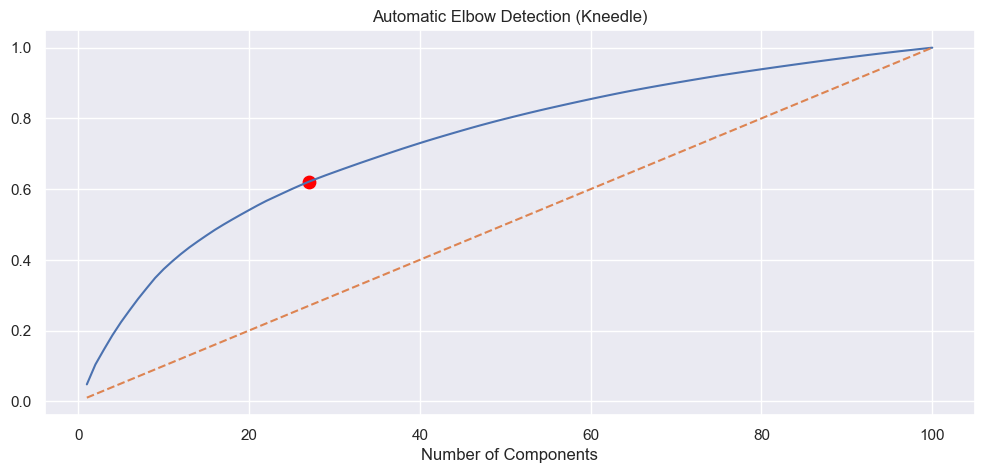

In [132]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Male; Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

### UMAP
* UMAP (Uniform Manifold Approximation and Projection) is a modern, high-performance algorithm used for dimensionality reduction. It is often considered the successor to t-SNE because it is significantly faster and better at preserving the "global structure" of your data (how far apart different groups are) while still showing the "local structure" (how similar items are within a group).
* Uniform Manifold Approximation and Projection (UMAP) is a fast, non-linear dimensionality reduction algorithm used to visualize high-dimensional data in 2D or 3D while preserving both local and global structure. Grounded in topological data analysis, it is widely used in genomics, machine learning, and data science for clustering and reducing computational complexity, often outperforming `t-SNE` in speed and retention of global structure. 
* SVD & UMAP give you the strongest, most complete medication‑phenotype (latent (hidden) grouping that emerges when you look at the whole "bag" of drugs) representation.

In [133]:
from umap import UMAP

# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_m['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_m["med_umap_1d"] = umap_1d_score

# shape
df_m.shape

(21365, 115)

#### Female

In [134]:
# TF‑IDF embedding
tfidf = TfidfVectorizer(
    token_pattern=r'\s*([^,]+?)\s*(?:,|$)',   # captures each medication without leading/trailing spaces
    lowercase=False
)

# used in clustering
X_meds_female = tfidf.fit_transform(df_f["Meds_DON"])

# shape
X_meds_female.shape

(8933, 2363)

In [135]:
# instantiate
svd = TruncatedSVD(
    n_components=100,      
    random_state=SEED
)

X_meds_svd = svd.fit_transform(X_meds_female)

print(X_meds_svd.shape)
print(svd.explained_variance_ratio_.sum())

(8933, 100)
0.6952892057720629


Optimal number of SVD components (Kneedle): 26


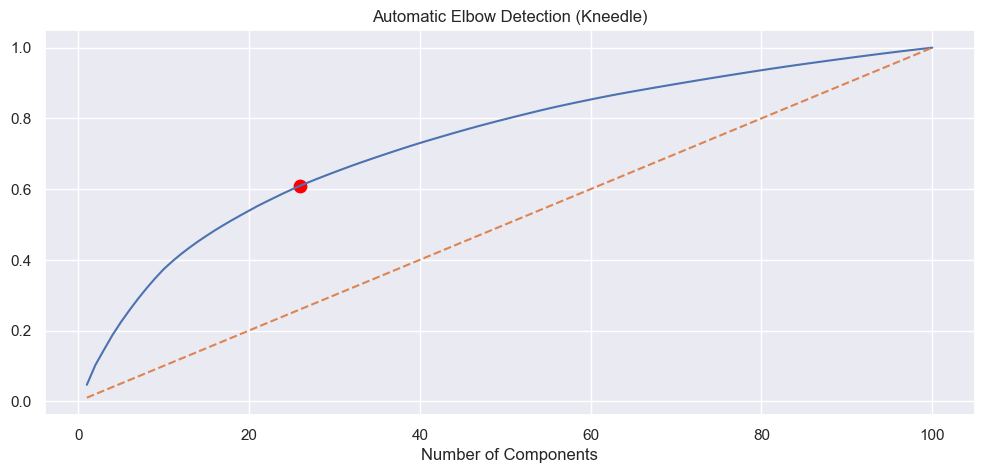

In [136]:
# cumulative sum
cum_evr = np.cumsum(svd.explained_variance_ratio_)

# Normalize cumulative curve (required for Kneedle)
x = np.arange(1, len(cum_evr) + 1)
y = cum_evr / cum_evr.max()

# Compute the "difference curve"
diff = y - (x / x.max())

# Knee = point of maximum difference
knee = np.argmax(diff) + 1   # +1 because index starts at 0
# Kneedle is an algorithm designed to automatically detect the “knee” or “elbow” in a curve,
# The point where adding more components stops giving meaningful improvement.
print("Optimal number of SVD components (Kneedle):", knee)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(x, y, label="Cumulative Explained Variance")
plt.plot(x, x/x.max(), '--', label="Reference Line")
plt.scatter(knee, y[knee-1], color='red', s=80, label=f"Knee = {knee}")
plt.title("Automatic Elbow Detection (Kneedle)")
plt.xlabel("Number of Components")
plt.plot();

In [137]:
# instantiate
umap_1d = UMAP(
    n_components=1,
    n_neighbors=15,    # 15 works so well for text‑derived embeddings
    min_dist=0.0,      # points can collapse tightly; sharp clusters; highly compressed
    metric="cosine",   # only if you feed UMAP the raw TF‑IDF matrix
    n_jobs=1,          # use with random_state for 1D
    init="random",     # more stable in 1D
    random_state=SEED
)

# get first score
umap_1d_score = umap_1d.fit_transform(X_meds_svd)[:, 0]

# add one linear axis score from SVD
df_f['med_svd_score'] =  X_meds_svd[:,0]

# capturing rare, local phenotypes and uses a much richer representation
df_f["med_umap_1d"] = umap_1d_score

# shape
df_f.shape

(8933, 116)

In [138]:
# check for NaNs
df_m.isna().any().any(), df_f.isna().any().any()

(np.False_, np.False_)

## Write to Disk: Donor Data

In [139]:
# save data: heart dataset
u.write_to_file(df_f, 'Donor_Female_Heart',path='../Data/', format='pkl')
u.write_to_file(df_m, 'Donor_Male_Heart',path='../Data/', format='pkl')

8,933 records written to ../Data/Donor_Female_Heart.pkl
21,365 records written to ../Data/Donor_Male_Heart.pkl
